# Proyecto Final: Agricultura y Ganadería Global


In [1]:
import pandas as pd
import numpy as np
import json
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1.2 Rutas de archivos

In [2]:
RAW_DATA = "../data/raw/"
PROCESSED_DATA = "../data/processed/"

## 1.3 Carga de datos

### Datos estructurados (CSV)

In [3]:
produccion_agricola = pd.read_csv(RAW_DATA + "structured/produccion_agricola.csv")
produccion_ganadera = pd.read_csv(RAW_DATA + "structured/produccion_ganadera.csv")
precios_mercado = pd.read_csv(RAW_DATA + "precios_mercado.csv")
imagenes_metadata = pd.read_csv(RAW_DATA + "structured/imagenes_metadata.csv")

with open(RAW_DATA + "semi_structured/condiciones_climaticas.json", "r", encoding="utf-8") as f:
    condiciones_climaticas_raw = json.load(f)

politicas_agricolas_tree = ET.parse(RAW_DATA + "semi_structured/politicas_agricolas.xml")

noticias_agricolas = pd.read_json(RAW_DATA + "unstructured/noticias_agricolas.jsonl", lines=True)

with open(RAW_DATA + "unstructured/reportes_plagas.txt", "r", encoding="utf-8") as f:
    reportes_plagas_raw = f.readlines()

### Transformación de datos semi-estructurados y no estructurados a DataFrame

In [4]:
filas_clima = []
for pais in condiciones_climaticas_raw:
    for region in pais["regiones"]:
        for dato in region["datos_climaticos"]:
            fila = {
                "pais": pais["pais"],
                "codigo_iso": pais["codigo_iso"],
                "region": region["nombre"],
                **dato
            }
            # Convertir eventos_extremos (lista) a string para evitar problemas
            fila["eventos_extremos"] = ", ".join(dato.get("eventos_extremos", []))
            filas_clima.append(fila)

condiciones_climaticas = pd.DataFrame(filas_clima)
print(f"condiciones_climaticas: {condiciones_climaticas.shape}")
condiciones_climaticas.head()

condiciones_climaticas: (200, 13)


,pais,codigo_iso,region,anio,temperatura_promedio,precipitacion_total,eventos_extremos,meses_estres_hidrico,indice_aridez,temperatura_maxima,temperatura_minima,humedad_relativa_promedio,dias_con_heladas
0,Argentina,ARG,Pampa Húmeda,2011,16.9,1050,,1,17.26,22.3,3.6,64,19
1,Argentina,ARG,Pampa Húmeda,2012,18.7,518,,5,7.69,25.8,6.7,72,70
2,Argentina,ARG,Pampa Húmeda,2013,21.2,1390,"ola_calor, sequia_moderada",0,18.21,31.4,9.9,70,17
3,Argentina,ARG,Pampa Húmeda,2014,17.2,731,,5,11.81,29.2,5.9,40,20
4,Argentina,ARG,Pampa Húmeda,2015,16.8,589,,5,9.74,23.4,6.3,41,56


In [5]:
root = politicas_agricolas_tree.getroot()

filas_subsidios = []
for pais in root.findall("pais"):
    for subsidio in pais.findall("subsidio"):
        filas_subsidios.append({
            "pais": pais.get("nombre"),
            "codigo_iso": pais.get("codigo"),
            "tipo": subsidio.get("tipo"),
            "anio": int(subsidio.get("anio")),
            "monto_usd": int(subsidio.get("monto")),
            "beneficiarios": int(subsidio.get("beneficiarios")),
        })

filas_regulaciones = []
for pais in root.findall("pais"):
    for reg in pais.findall("regulacion"):
        filas_regulaciones.append({
            "pais": pais.get("nombre"),
            "codigo_iso": pais.get("codigo"),
            "tipo": reg.get("tipo"),
            "vigente": reg.get("vigente") == "true",
            "anio_implementacion": int(reg.get("anio_implementacion")),
        })

subsidios = pd.DataFrame(filas_subsidios)
regulaciones = pd.DataFrame(filas_regulaciones)

print(f"subsidios: {subsidios.shape}")
display(subsidios.head())
print(f"\nregulaciones: {regulaciones.shape}")
display(regulaciones.head())

subsidios: (37, 6)


,pais,codigo_iso,tipo,anio,monto_usd,beneficiarios
0,Argentina,ARG,maquinaria,2021,25542386,1914
1,Argentina,ARG,expansion_frontera_agricola,2023,12595066,10898
2,Argentina,ARG,investigacion_desarrollo,2019,15562206,7215
3,Argentina,ARG,fertilizantes,2021,32694726,10823
4,Brasil,BRA,expansion_frontera_agricola,2019,33704977,44633



regulaciones: (29, 5)


,pais,codigo_iso,tipo,vigente,anio_implementacion
0,Argentina,ARG,pesticidas_neonicotinoides,True,2010
1,Argentina,ARG,uso_agua,False,2012
2,Argentina,ARG,etanol_mezcla,False,2013
3,Brasil,BRA,deforestacion,True,2018
4,Brasil,BRA,reservas_legales,False,2017


In [6]:
filas_plagas = []
for linea in reportes_plagas_raw:
    partes = [p.strip() for p in linea.strip().split(",")]
    fila = {}
    fila["fecha"] = partes[0].strip()
    for parte in partes[1:]:
        if ":" in parte:
            clave, valor = parte.split(":", 1)
            fila[clave.strip()] = valor.strip()
    filas_plagas.append(fila)

reportes_plagas = pd.DataFrame(filas_plagas)
print(f"reportes_plagas: {reportes_plagas.shape}")
reportes_plagas.head()

reportes_plagas: (100, 11)


,fecha,Región,País,Cultivo,Plaga detectada,Severidad,Área afectada,Tratamiento aplicado,Eficacia,Pérdida estimada,Enfermedad detectada
0,2020-01-01,Región Principal,China,Arroz,Barrenador del tallo,Media,2745ha,Químico (Epoxiconazole),93%,26%,NaN
1,2020-01-13,Región Principal,Francia,Caña de azúcar,Chinche marrón,Crítica,3943ha,Cultural (Control manual),97%,17%,NaN
2,2020-01-15,Cerrado,Brasil,Maíz,Oruga militar tardía,Alta,10ha,Cultural (Fecha de siembra ajustada),82%,38%,NaN
3,2020-01-18,Mata Atlántica,Brasil,Maíz,Barrenador del tallo,Crítica,3064ha,Biológico (Trichogramma spp.),83%,3%,NaN
4,2020-01-23,Patagonia,Argentina,Soja,Langosta,Media,995ha,Biológico (Trichogramma spp.),75%,2%,NaN


## 1.4 Exploración inicial de los datos

In [7]:
def explorar_df(df, nombre):
    print(f"{'='*60}")
    print(f" {nombre}")
    print(f"{'='*60}")
    print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
    
    try:
        print(f"Duplicados: {df.duplicated().sum()}")
    except TypeError:
        print("Duplicados: No se puede calcular (columnas con listas)")
    
    nulos = df.isnull().sum()
    if nulos.sum() > 0:
        print(f"\nNulos:")
        print(nulos[nulos > 0])
    else:
        print(f"\nNulos: Ninguno")
    
    print(f"\nTipos de datos:")
    print(df.dtypes)
    print(f"\n{'─'*60}")
    display(df.head())
    print()
    display(df.describe())
    print(f"\n")

In [8]:
datasets = {
    "Producción Agrícola": produccion_agricola,
    "Producción Ganadera": produccion_ganadera,
    "Precios de Mercado": precios_mercado,
    "Imágenes Metadata": imagenes_metadata,
    "Condiciones Climáticas": condiciones_climaticas,
    "Subsidios": subsidios,
    "Regulaciones": regulaciones,
    "Noticias Agrícolas": noticias_agricolas,
    "Reportes de Plagas": reportes_plagas,
}

for nombre, df in datasets.items():
    explorar_df(df, nombre)

 Producción Agrícola
Filas: 1200 | Columnas: 11
Duplicados: 0

Nulos: Ninguno

Tipos de datos:
pais                        str
codigo_iso                  str
region                      str
cultivo                     str
anio                      int64
superficie_hectareas      int64
rendimiento_ton_ha      float64
produccion_ton            int64
fertilizantes_kg_ha       int64
agua_riego_m3_ha          int64
tendencia_5_anios       float64
dtype: object

────────────────────────────────────────────────────────────


,pais,codigo_iso,region,cultivo,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,tendencia_5_anios
0,Argentina,ARG,América del Sur,Soja,2011,4703643,2.22,10465461,105,4811,0.000536
1,Argentina,ARG,América del Sur,Maíz,2011,3371781,8.45,28485921,164,5557,0.030943
2,Argentina,ARG,América del Sur,Cebada,2011,1661577,2.77,4596917,105,6514,-0.039779
3,Argentina,ARG,América del Sur,Té,2011,188518,3.07,577886,236,8527,0.003623
4,Argentina,ARG,América del Sur,Algodón,2011,1638327,1.18,1929756,276,6925,0.007735


,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,tendencia_5_anios
count,1200.000000,1.200000e+03,1200.000000,1.200000e+03,1200.000000,1200.000000,1200.000000
mean,2015.500000,2.351555e+06,12.878433,5.329724e+07,172.769167,5464.924167,-0.000749
std,2.873479,2.379629e+06,27.418970,1.557934e+08,72.205648,2598.508894,0.028879
min,2011.000000,9.770000e+02,0.430000,2.775000e+03,50.000000,1001.000000,-0.049991
25%,2013.000000,4.013445e+05,2.227500,9.711170e+05,109.750000,3184.250000,-0.025279
50%,2015.500000,1.589487e+06,3.500000,5.880648e+06,173.000000,5526.500000,-0.001155
75%,2018.000000,3.447043e+06,5.932500,1.745015e+07,234.250000,7746.250000,0.023543
max,2020.000000,1.263063e+07,158.450000,1.154381e+09,300.000000,9998.000000,0.049957




 Producción Ganadera
Filas: 600 | Columnas: 9
Duplicados: 0

Nulos: Ninguno

Tipos de datos:
pais                           str
anio                         int64
tipo_ganado                    str
cabezas_ganado               int64
produccion_carne_ton         int64
produccion_leche_lt          int64
emisiones_ch4_ton_co2eq      int64
intensidad_emisiones       float64
eficiencia_carne           float64
dtype: object

────────────────────────────────────────────────────────────


,pais,anio,tipo_ganado,cabezas_ganado,produccion_carne_ton,produccion_leche_lt,emisiones_ch4_ton_co2eq,intensidad_emisiones,eficiencia_carne
0,Argentina,2011,bovino,18160590,1857394,2355425160,1121740,0.062,0.1023
1,Argentina,2011,porcino,13481224,1528896,0,1984357,0.147,0.1134
2,Argentina,2011,avicola,979196737,1290153,0,10160819,0.010,0.0013
3,Argentina,2011,ovino,13789178,477282,329191349,5061273,0.367,0.0346
4,Argentina,2011,caprino,2045715,345732,454558689,284966,0.139,0.1690


...

,fecha,fuente,titular,contenido,impacto_cultivos,severidad,paises_afectados,categoria,id_noticia
0,2021-01-01,Bloomberg Commodities,Nueva política agrícola en Canadá busca mejora...,El gobierno de Canadá ha anunciado nuevas medi...,[todos],alta,[Australia],politica,NEWS5336
1,2021-01-11,Dairy Reporter,Ola de calor reduce rendimientos de Arroz,Eventos climáticos extremos están afectando la...,[Arroz],baja,"[India, Argentina, Rusia]",clima,NEWS8360
2,2021-01-19,World Grain,Sequía afecta proyecciones de cosecha en Alemania,Eventos climáticos extremos están afectando la...,[Maíz],alta,"[Argentina, México]",clima,NEWS6016
3,2021-02-13,Farm Journal,Nueva política agrícola en Argentina busca mej...,El gobierno de Argentina ha anunciado nuevas m...,[todos],media,"[India, México, Nueva Zelanda]",comercio,NEWS5711
4,2021-03-10,Reuters Agricultura,Demanda china impulsa mercado de carne_bovina,El mercado internacional de carne_bovina muest...,[carne_bovina],alta,"[India, Argentina, Nueva Zelanda]",mercado,NEWS8036


,fecha,fuente,titular,contenido,impacto_cultivos,severidad,paises_afectados,categoria,id_noticia
count,60,60,60,60,60,60,60,60,60
unique,60,7,32,35,12,3,44,6,60
top,2021-01-01,Bloomberg Commodities,Nueva política agrícola en Italia busca mejora...,El gobierno de Italia ha anunciado nuevas medi...,[todos],alta,[Australia],comercio,NEWS5336
freq,1,16,6,6,40,23,4,15,1




 Reportes de Plagas
Filas: 100 | Columnas: 11
Duplicados: 0

Nulos:
Plaga detectada         26
Enfermedad detectada    74
dtype: int64

Tipos de datos:
fecha                   str
Región                  str
País                    str
Cultivo                 str
Plaga detectada         str
Severidad               str
Área afectada           str
Tratamiento aplicado    str
Eficacia                str
Pérdida estimada        str
Enfermedad detectada    str
dtype: object

────────────────────────────────────────────────────────────


,fecha,Región,País,Cultivo,Plaga detectada,Severidad,Área afectada,Tratamiento aplicado,Eficacia,Pérdida estimada,Enfermedad detectada
0,2020-01-01,Región Principal,China,Arroz,Barrenador del tallo,Media,2745ha,Químico (Epoxiconazole),93%,26%,NaN
1,2020-01-13,Región Principal,Francia,Caña de azúcar,Chinche marrón,Crítica,3943ha,Cultural (Control manual),97%,17%,NaN
2,2020-01-15,Cerrado,Brasil,Maíz,Oruga militar tardía,Alta,10ha,Cultural (Fecha de siembra ajustada),82%,38%,NaN
3,2020-01-18,Mata Atlántica,Brasil,Maíz,Barrenador del tallo,Crítica,3064ha,Biológico (Trichogramma spp.),83%,3%,NaN
4,2020-01-23,Patagonia,Argentina,Soja,Langosta,Media,995ha,Biológico (Trichogramma spp.),75%,2%,NaN


,fecha,Región,País,Cultivo,Plaga detectada,Severidad,Área afectada,Tratamiento aplicado,Eficacia,Pérdida estimada,Enfermedad detectada
count,100,100,100,100,74,100,100,100,100,100,26
unique,100,20,8,10,8,4,100,13,29,38,9
top,2020-01-01,Región Principal,China,Arroz,Ácaro,Baja,2745ha,Biológico (Trichogramma spp.),96%,32%,Roya de la hoja
freq,1,45,16,19,16,28,1,11,7,9,6


## 1.5 Limpieza de datos

Los únicos nulos detectados están en **Reportes de Plagas**, en las columnas `Plaga detectada` y `Enfermedad detectada`. Esto es lógico: un reporte puede ser de plaga o de enfermedad, pero no de ambas. Se rellenan con "Desconocido" para mantener la consistencia.

Además se corrigen los tipos de datos:
- Columnas de fecha → `datetime`
- Columnas numéricas almacenadas como texto → tipo numérico

In [9]:
print("Nulos antes de limpieza:")
print(reportes_plagas.isnull().sum())
print()

reportes_plagas.fillna("Desconocido", inplace=True)

print("Nulos después de limpieza:")
print(reportes_plagas.isnull().sum())

Nulos antes de limpieza:
fecha                    0
Región                   0
País                     0
Cultivo                  0
Plaga detectada         26
Severidad                0
Área afectada            0
Tratamiento aplicado     0
Eficacia                 0
Pérdida estimada         0
Enfermedad detectada    74
dtype: int64

Nulos después de limpieza:
fecha                   0
Región                  0
País                    0
Cultivo                 0
Plaga detectada         0
Severidad               0
Área afectada           0
Tratamiento aplicado    0
Eficacia                0
Pérdida estimada        0
Enfermedad detectada    0
dtype: int64


In [10]:
produccion_agricola["anio"] = pd.to_datetime(produccion_agricola["anio"], format="%Y")
produccion_ganadera["anio"] = pd.to_datetime(produccion_ganadera["anio"], format="%Y")
precios_mercado["fecha"] = pd.to_datetime(precios_mercado["fecha"])
imagenes_metadata["fecha"] = pd.to_datetime(imagenes_metadata["fecha"])
condiciones_climaticas["anio"] = pd.to_datetime(condiciones_climaticas["anio"], format="%Y")
noticias_agricolas["fecha"] = pd.to_datetime(noticias_agricolas["fecha"])
reportes_plagas["fecha"] = pd.to_datetime(reportes_plagas["fecha"])
subsidios["anio"] = pd.to_datetime(subsidios["anio"], format="%Y")

Guardamos los datos limpios

In [11]:
import os
os.makedirs(PROCESSED_DATA, exist_ok=True)

produccion_agricola.to_csv(PROCESSED_DATA + "produccion_agricola.csv", index=False)
produccion_ganadera.to_csv(PROCESSED_DATA + "produccion_ganadera.csv", index=False)
precios_mercado.to_csv(PROCESSED_DATA + "precios_mercado.csv", index=False)
imagenes_metadata.to_csv(PROCESSED_DATA + "imagenes_metadata.csv", index=False)
condiciones_climaticas.to_csv(PROCESSED_DATA + "condiciones_climaticas.csv", index=False)
subsidios.to_csv(PROCESSED_DATA + "subsidios.csv", index=False)
regulaciones.to_csv(PROCESSED_DATA + "regulaciones.csv", index=False)
noticias_agricolas.to_csv(PROCESSED_DATA + "noticias_agricolas.csv", index=False)
reportes_plagas.to_csv(PROCESSED_DATA + "reportes_plagas.csv", index=False)

print("Datos limpios guardados en data/processed/")

Datos limpios guardados en data/processed/


# 2. Análisis Exploratorio de Datos (EDA)

## 2.1 Producción Agrícola - Análisis de correlaciones

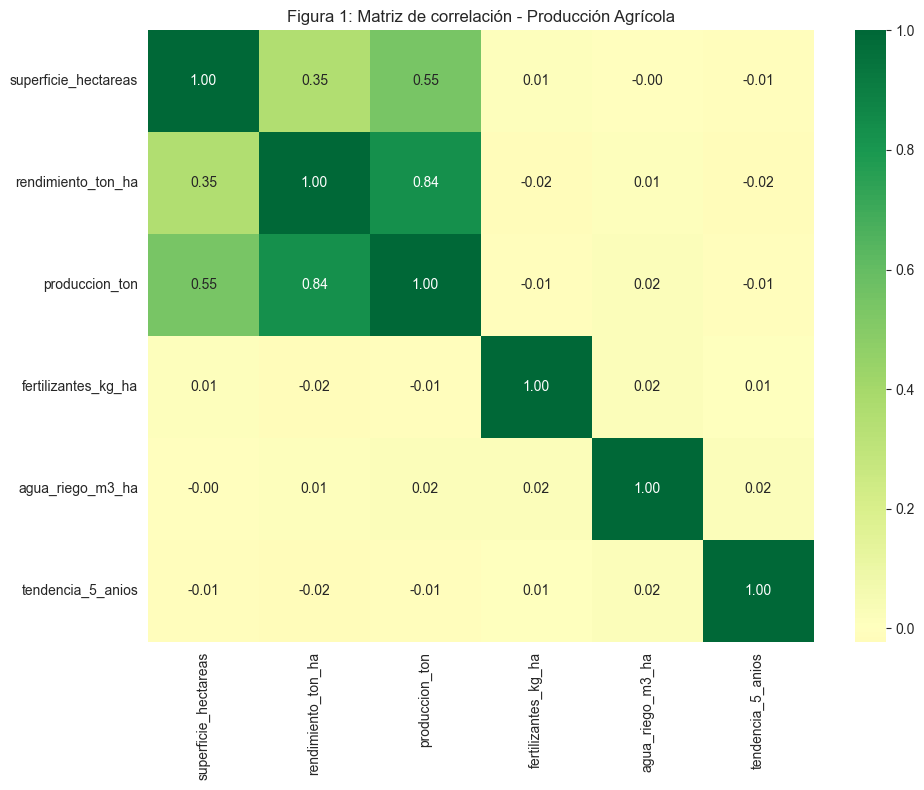

In [12]:
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

import os
os.makedirs("../docs/figuras", exist_ok=True)

cols_numericas = ["superficie_hectareas", "rendimiento_ton_ha", "produccion_ton", 
                  "fertilizantes_kg_ha", "agua_riego_m3_ha", "tendencia_5_anios"]

fig, ax = plt.subplots(figsize=(10, 8))
corr = produccion_agricola[cols_numericas].corr()
sns.heatmap(corr, annot=True, cmap="RdYlGn", center=0, fmt=".2f", ax=ax)
ax.set_title("Figura 1: Matriz de correlación - Producción Agrícola")
plt.tight_layout()
fig.savefig("../docs/figuras/fig01_correlacion_agricola.png", bbox_inches="tight")
plt.show()

**Verificación numérica de correlaciones** — valores exactos para citar en el documento

In [13]:
# Correlaciones especificas entre variables agricolas
matriz_corr = produccion_agricola[cols_numericas].corr().round(4)
display(matriz_corr)

fert_rend = matriz_corr.loc['fertilizantes_kg_ha', 'rendimiento_ton_ha']
agua_rend = matriz_corr.loc['agua_riego_m3_ha', 'rendimiento_ton_ha']
sup_prod  = matriz_corr.loc['superficie_hectareas', 'produccion_ton']
rend_prod = matriz_corr.loc['rendimiento_ton_ha', 'produccion_ton']

print('CORRELACIONES CLAVE:')
print('  Fertilizantes - Rendimiento: r =', round(fert_rend, 4))
print('  Agua riego    - Rendimiento: r =', round(agua_rend, 4))
print('  Superficie    - Produccion:  r =', round(sup_prod, 4))
print('  Rendimiento   - Produccion:  r =', round(rend_prod, 4))

sev_alta = reportes_plagas['Severidad'].isin(['Alta', 'Crítica'])
pct_severas = sev_alta.mean() * 100
print('Plagas severidad Alta/Critica:', round(pct_severas, 1), '%')


,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,tendencia_5_anios
superficie_hectareas,1.0000,0.3530,0.5455,0.0090,-0.0027,-0.0129
rendimiento_ton_ha,0.3530,1.0000,0.8358,-0.0230,0.0143,-0.0152
produccion_ton,0.5455,0.8358,1.0000,-0.0137,0.0247,-0.0123
fertilizantes_kg_ha,0.0090,-0.0230,-0.0137,1.0000,0.0177,0.0076
agua_riego_m3_ha,-0.0027,0.0143,0.0247,0.0177,1.0000,0.0225
tendencia_5_anios,-0.0129,-0.0152,-0.0123,0.0076,0.0225,1.0000


CORRELACIONES CLAVE:
  Fertilizantes - Rendimiento: r = -0.023
  Agua riego    - Rendimiento: r = 0.0143
  Superficie    - Produccion:  r = 0.5455
  Rendimiento   - Produccion:  r = 0.8358
Plagas severidad Alta/Critica: 48.0 %


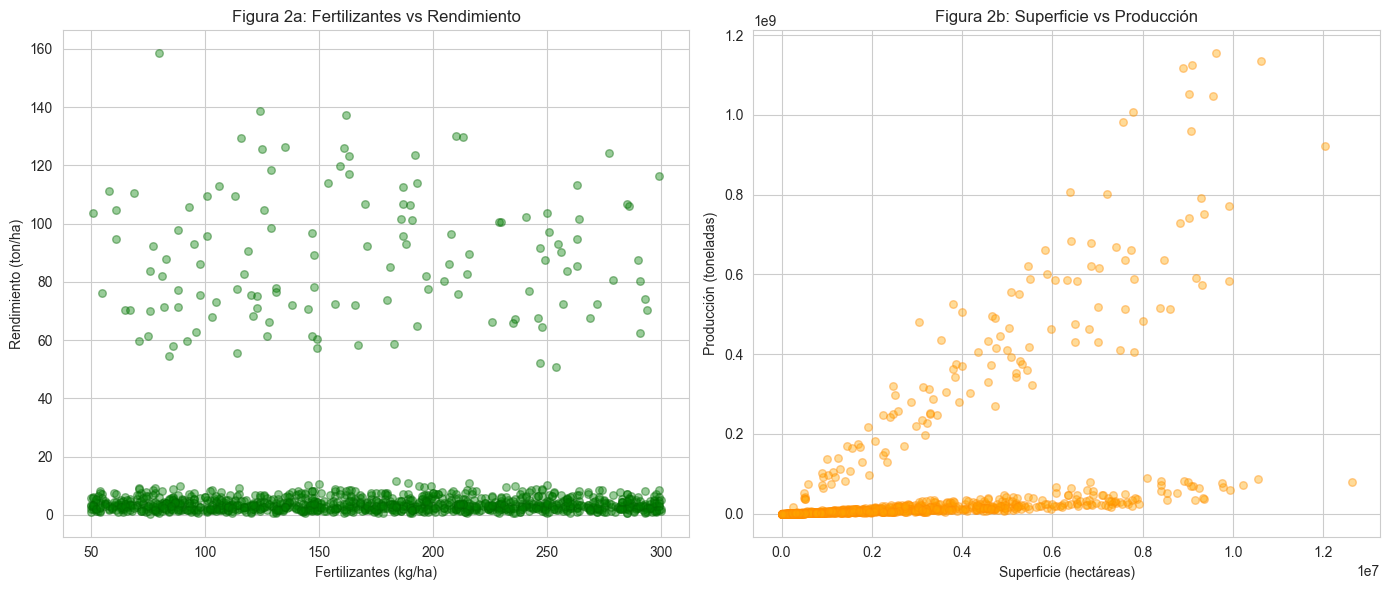

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(produccion_agricola["fertilizantes_kg_ha"], 
                produccion_agricola["rendimiento_ton_ha"], 
                alpha=0.4, c="green", edgecolors="darkgreen", s=30)
axes[0].set_xlabel("Fertilizantes (kg/ha)")
axes[0].set_ylabel("Rendimiento (ton/ha)")
axes[0].set_title("Figura 2a: Fertilizantes vs Rendimiento")

axes[1].scatter(produccion_agricola["superficie_hectareas"], 
                produccion_agricola["produccion_ton"], 
                alpha=0.4, c="orange", edgecolors="darkorange", s=30)
axes[1].set_xlabel("Superficie (hectáreas)")
axes[1].set_ylabel("Producción (toneladas)")
axes[1].set_title("Figura 2b: Superficie vs Producción")

plt.tight_layout()
fig.savefig("../docs/figuras/fig02_scatter_fertilizantes_superficie.png", bbox_inches="tight")
plt.show()

## 2.2 Análisis temporal - Tendencias de producción

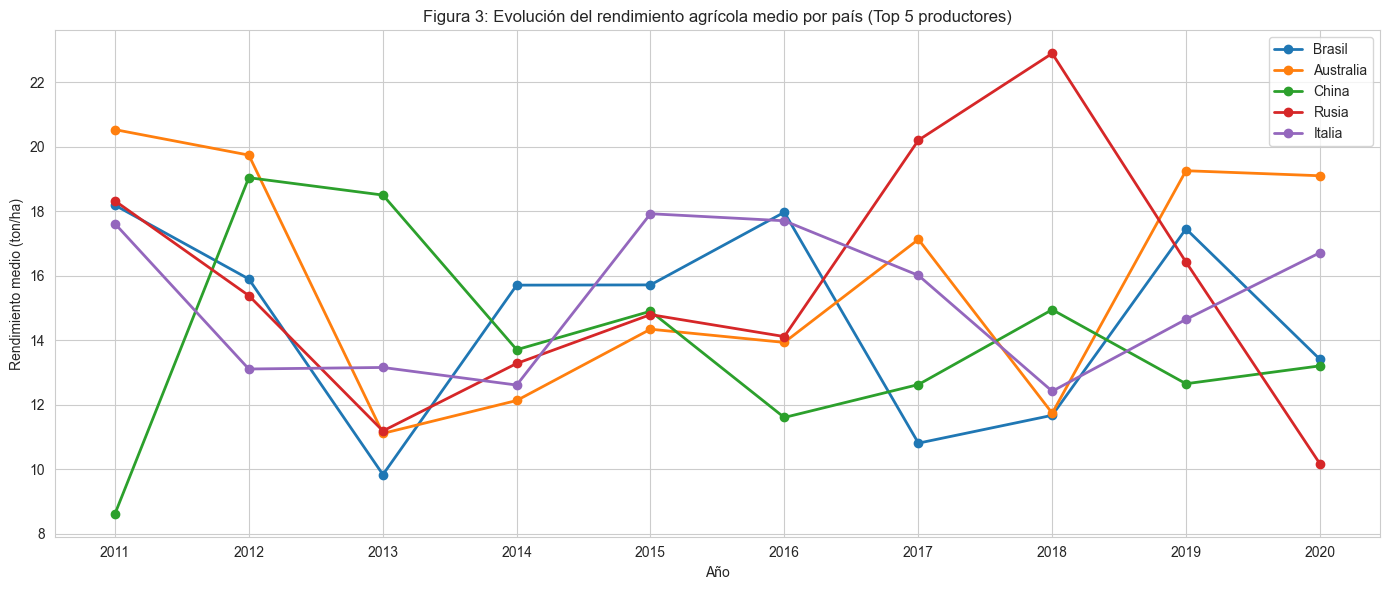

In [15]:
top_paises = produccion_agricola.groupby("pais")["produccion_ton"].sum().nlargest(5).index

fig, ax = plt.subplots(figsize=(14, 6))
for pais in top_paises:
    datos_pais = produccion_agricola[produccion_agricola["pais"] == pais]
    rend_por_anio = datos_pais.groupby("anio")["rendimiento_ton_ha"].mean()
    ax.plot(rend_por_anio.index, rend_por_anio.values, marker="o", label=pais, linewidth=2)

ax.set_xlabel("Año")
ax.set_ylabel("Rendimiento medio (ton/ha)")
ax.set_title("Figura 3: Evolución del rendimiento agrícola medio por país (Top 5 productores)")
ax.legend()
plt.tight_layout()
fig.savefig("../docs/figuras/fig03_evolucion_rendimiento.png", bbox_inches="tight")
plt.show()

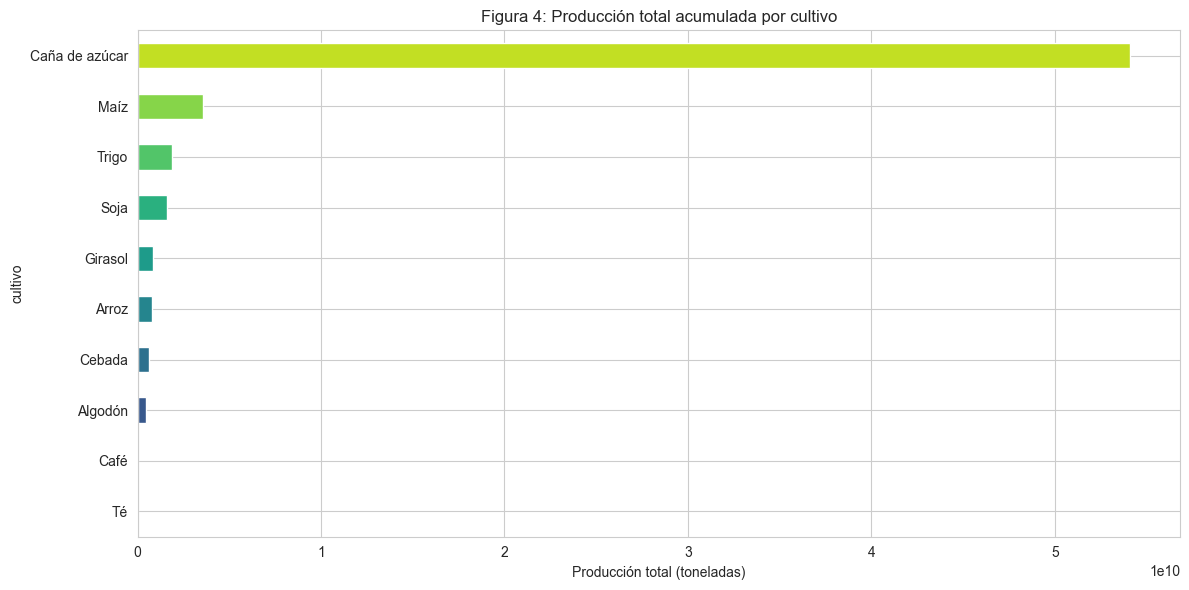

In [16]:
prod_por_cultivo = produccion_agricola.groupby("cultivo")["produccion_ton"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
prod_por_cultivo.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(prod_por_cultivo)))
ax.set_xlabel("Producción total (toneladas)")
ax.set_title("Figura 4: Producción total acumulada por cultivo")
plt.tight_layout()
fig.savefig("../docs/figuras/fig04_produccion_por_cultivo.png", bbox_inches="tight")
plt.show()

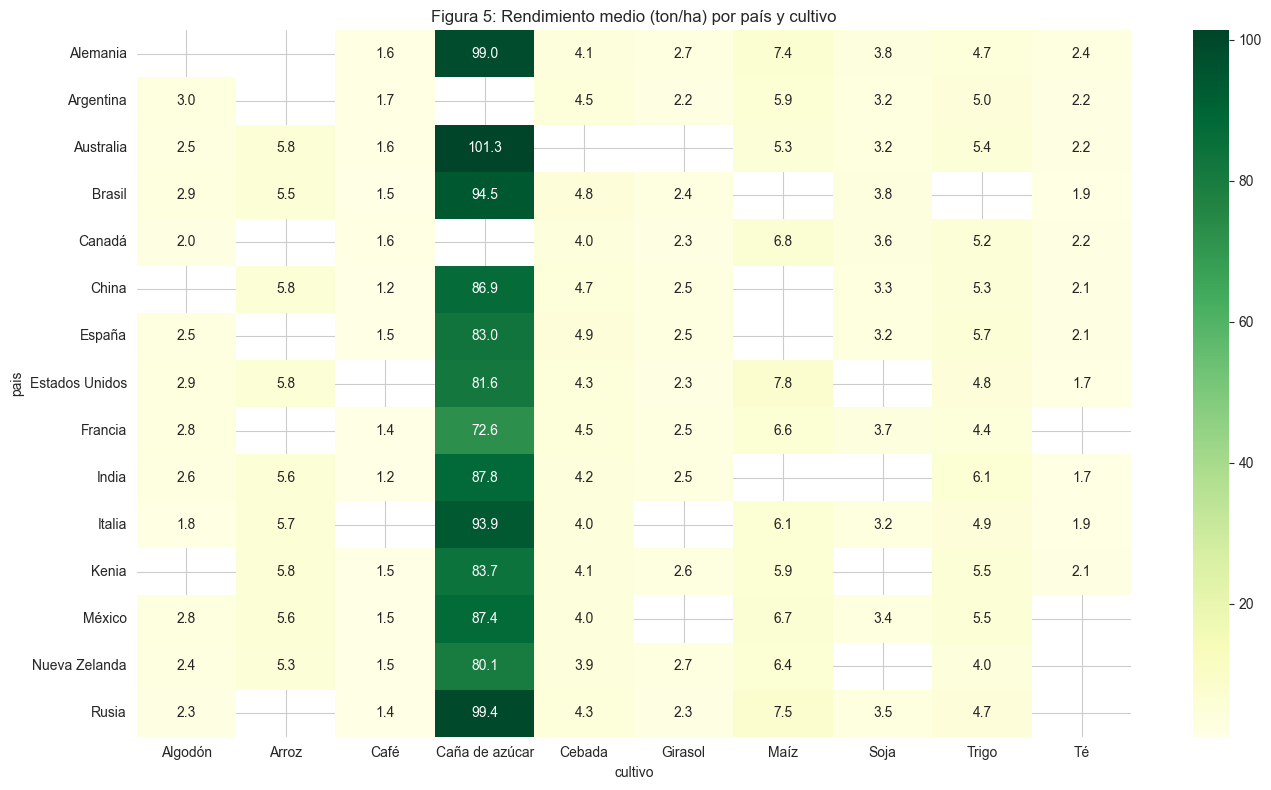

In [17]:
pivot_rendimiento = produccion_agricola.pivot_table(
    values="rendimiento_ton_ha", index="pais", columns="cultivo", aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_rendimiento, annot=True, fmt=".1f", cmap="YlGn", ax=ax)
ax.set_title("Figura 5: Rendimiento medio (ton/ha) por país y cultivo")
plt.tight_layout()
fig.savefig("../docs/figuras/fig05_heatmap_rendimiento.png", bbox_inches="tight")
plt.show()

## 2.3 Producción Ganadera

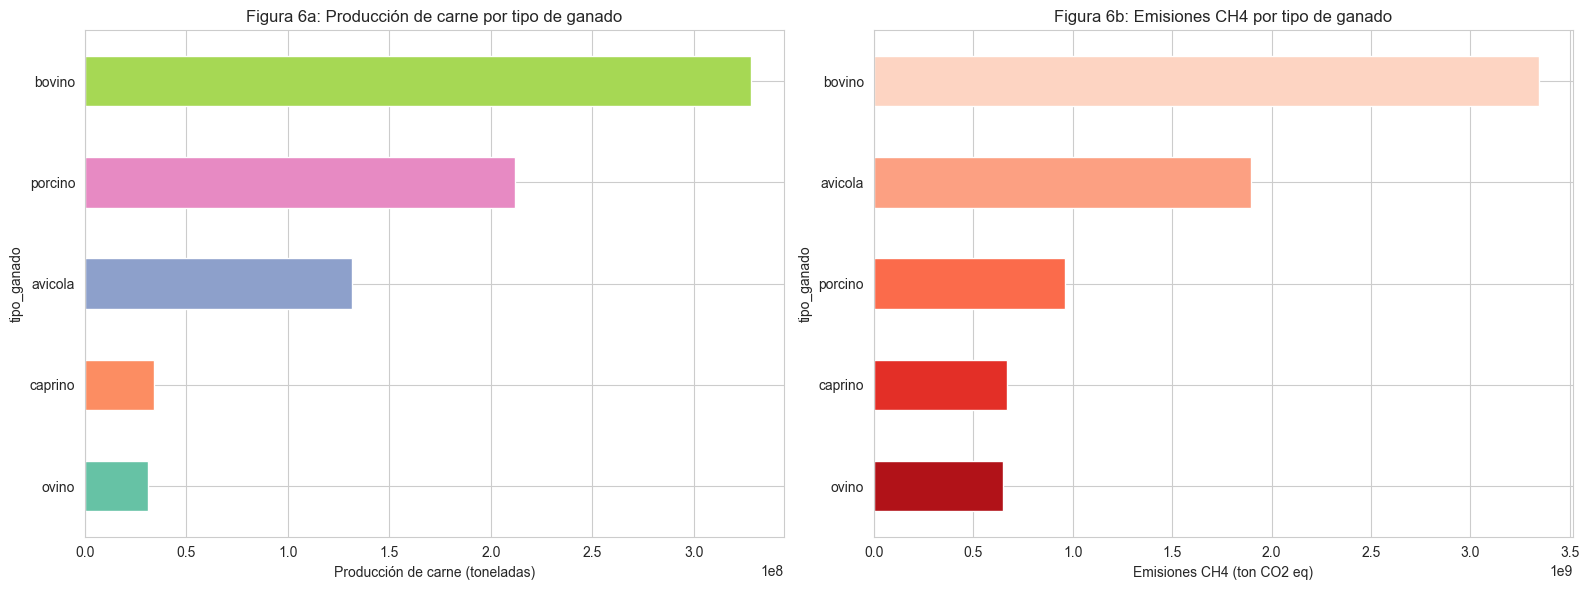

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

carne_por_tipo = produccion_ganadera.groupby("tipo_ganado")["produccion_carne_ton"].sum().sort_values()
carne_por_tipo.plot(kind="barh", ax=axes[0], color=sns.color_palette("Set2", len(carne_por_tipo)))
axes[0].set_xlabel("Producción de carne (toneladas)")
axes[0].set_title("Figura 6a: Producción de carne por tipo de ganado")

emisiones_por_tipo = produccion_ganadera.groupby("tipo_ganado")["emisiones_ch4_ton_co2eq"].sum().sort_values()
emisiones_por_tipo.plot(kind="barh", ax=axes[1], color=sns.color_palette("Reds_r", len(emisiones_por_tipo)))
axes[1].set_xlabel("Emisiones CH4 (ton CO2 eq)")
axes[1].set_title("Figura 6b: Emisiones CH4 por tipo de ganado")

plt.tight_layout()
fig.savefig("../docs/figuras/fig06_ganaderia_carne_emisiones.png", bbox_inches="tight")
plt.show()

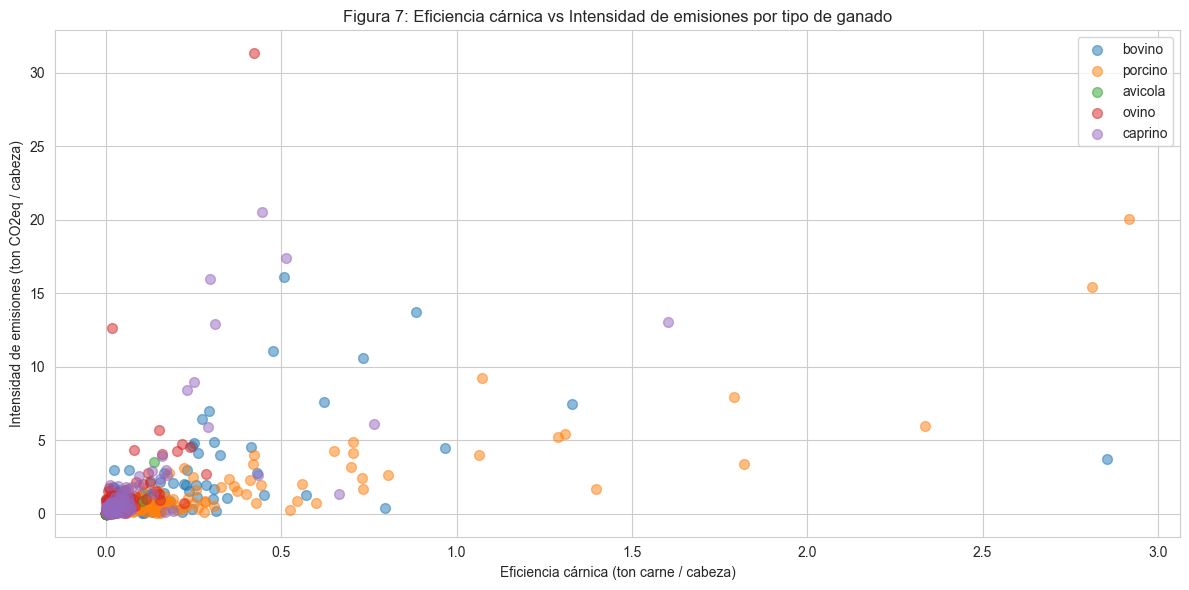

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
for tipo in produccion_ganadera["tipo_ganado"].unique():
    datos = produccion_ganadera[produccion_ganadera["tipo_ganado"] == tipo]
    ax.scatter(datos["eficiencia_carne"], datos["intensidad_emisiones"], 
              alpha=0.5, label=tipo, s=50)

ax.set_xlabel("Eficiencia cárnica (ton carne / cabeza)")
ax.set_ylabel("Intensidad de emisiones (ton CO2eq / cabeza)")
ax.set_title("Figura 7: Eficiencia cárnica vs Intensidad de emisiones por tipo de ganado")
ax.legend()
plt.tight_layout()
fig.savefig("../docs/figuras/fig07_eficiencia_vs_emisiones.png", bbox_inches="tight")
plt.show()

## 2.4 Precios de Mercado

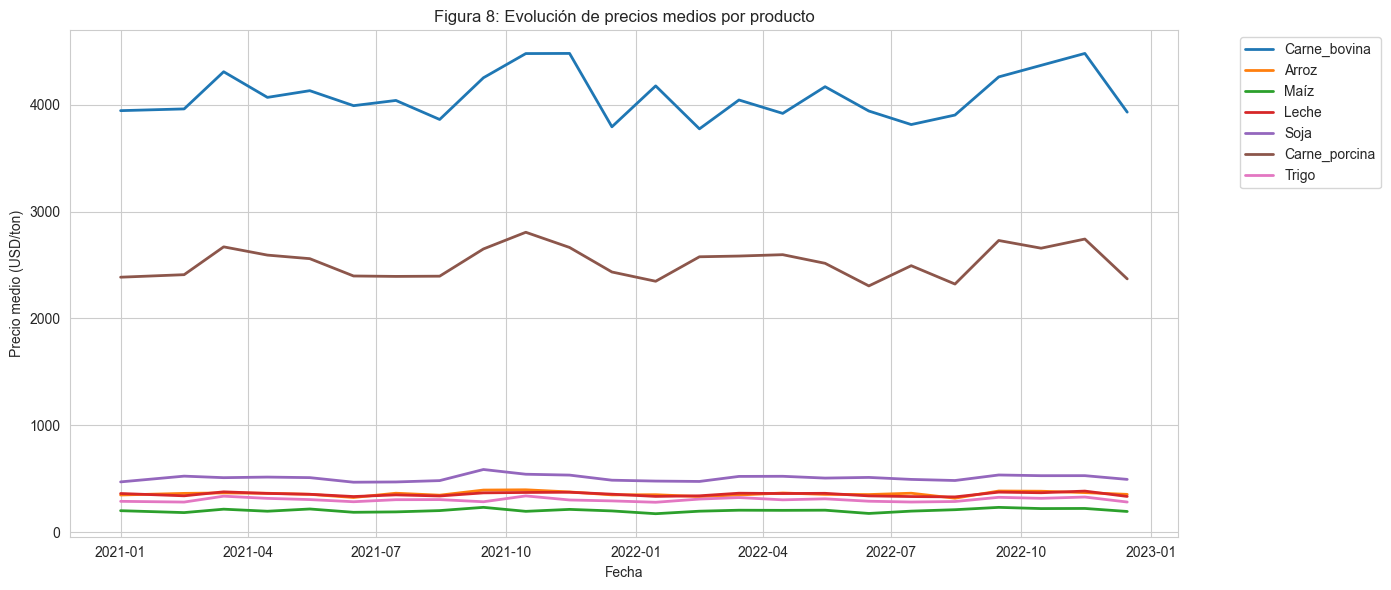

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))
for producto in precios_mercado["producto"].unique():
    datos = precios_mercado[precios_mercado["producto"] == producto]
    precio_medio = datos.groupby("fecha")["precio_usd_ton"].mean()
    ax.plot(precio_medio.index, precio_medio.values, label=producto, linewidth=2)

ax.set_xlabel("Fecha")
ax.set_ylabel("Precio medio (USD/ton)")
ax.set_title("Figura 8: Evolución de precios medios por producto")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
fig.savefig("../docs/figuras/fig08_evolucion_precios.png", bbox_inches="tight")
plt.show()

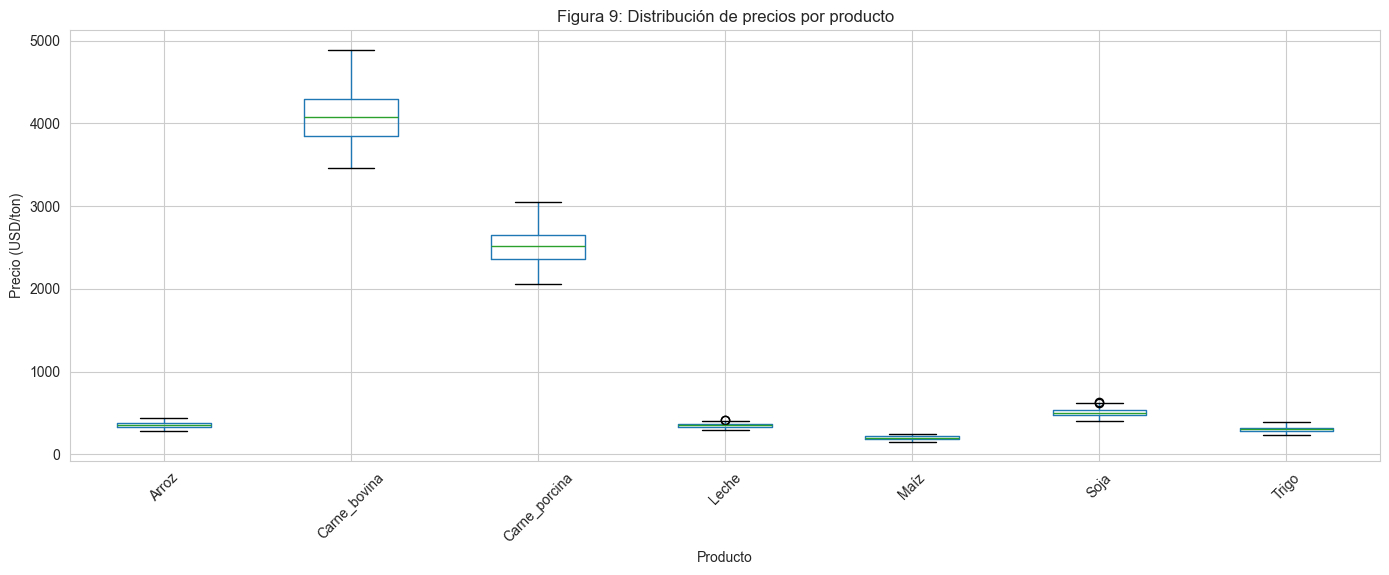

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))
precios_mercado.boxplot(column="precio_usd_ton", by="producto", ax=ax, rot=45)
ax.set_xlabel("Producto")
ax.set_ylabel("Precio (USD/ton)")
ax.set_title("Figura 9: Distribución de precios por producto")
plt.suptitle("")
plt.tight_layout()
fig.savefig("../docs/figuras/fig09_boxplot_precios.png", bbox_inches="tight")
plt.show()

## 2.5 Condiciones Climáticas

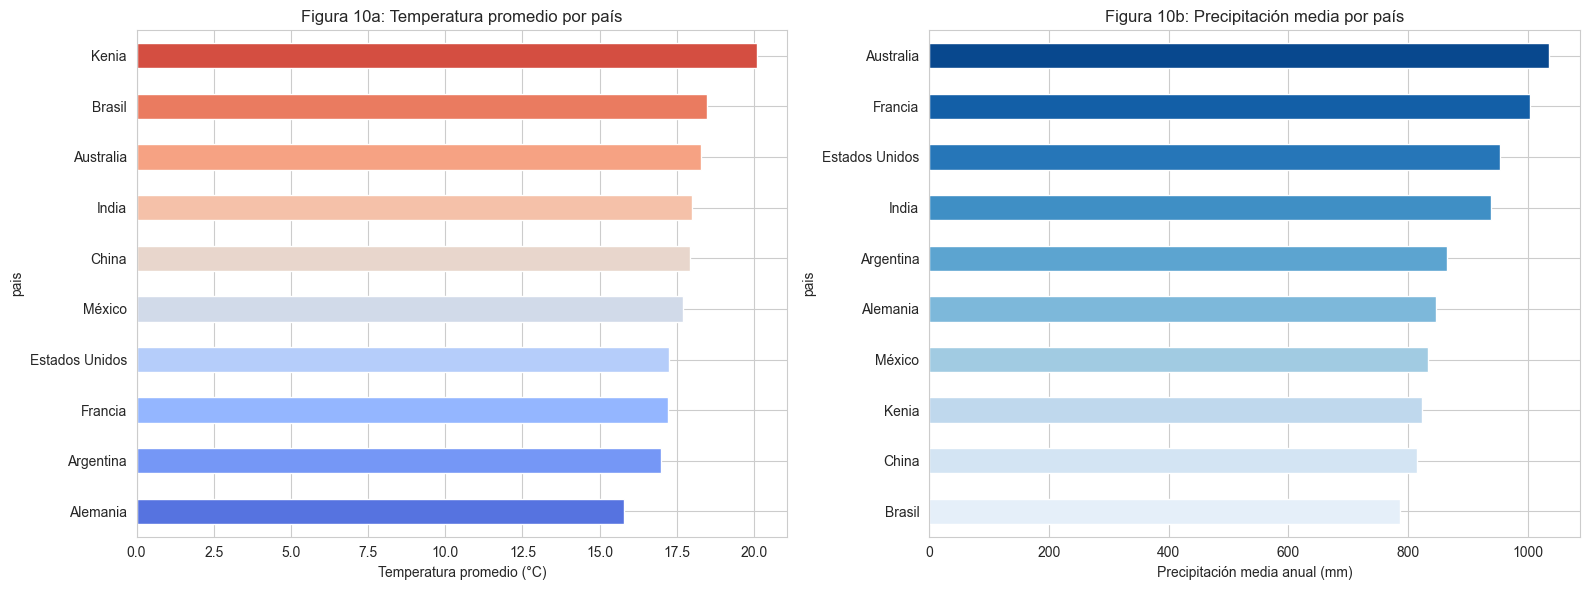

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

temp_por_pais = condiciones_climaticas.groupby("pais")["temperatura_promedio"].mean().sort_values()
temp_por_pais.plot(kind="barh", ax=axes[0], color=sns.color_palette("coolwarm", len(temp_por_pais)))
axes[0].set_xlabel("Temperatura promedio (°C)")
axes[0].set_title("Figura 10a: Temperatura promedio por país")

precip_por_pais = condiciones_climaticas.groupby("pais")["precipitacion_total"].mean().sort_values()
precip_por_pais.plot(kind="barh", ax=axes[1], color=sns.color_palette("Blues", len(precip_por_pais)))
axes[1].set_xlabel("Precipitación media anual (mm)")
axes[1].set_title("Figura 10b: Precipitación media por país")

plt.tight_layout()
fig.savefig("../docs/figuras/fig10_clima_por_pais.png", bbox_inches="tight")
plt.show()

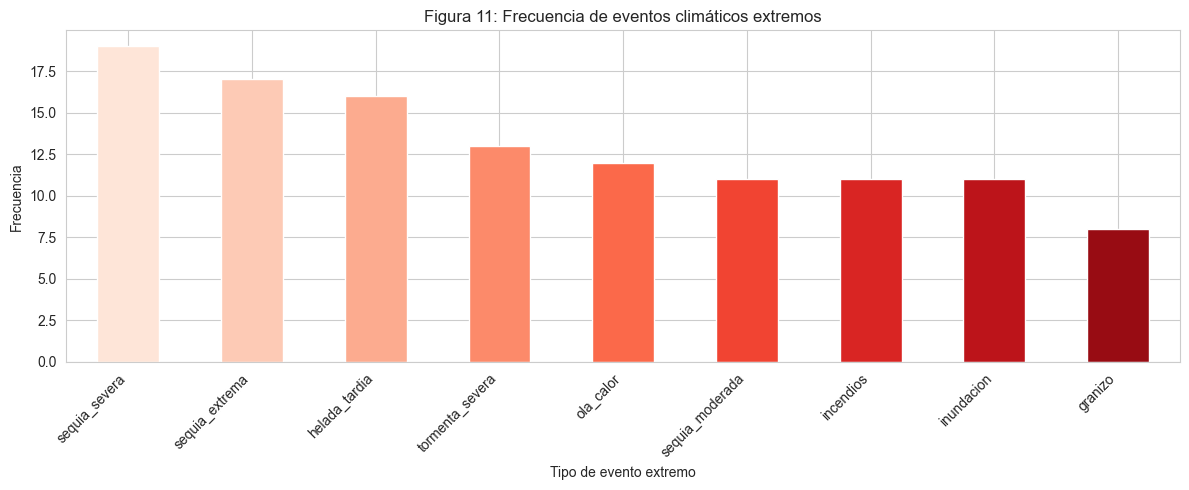

In [23]:
eventos = condiciones_climaticas[condiciones_climaticas["eventos_extremos"] != ""]
eventos_split = eventos["eventos_extremos"].str.split(", ").explode()

fig, ax = plt.subplots(figsize=(12, 5))
eventos_split.value_counts().plot(kind="bar", ax=ax, color=sns.color_palette("Reds", len(eventos_split.unique())))
ax.set_xlabel("Tipo de evento extremo")
ax.set_ylabel("Frecuencia")
ax.set_title("Figura 11: Frecuencia de eventos climáticos extremos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig("../docs/figuras/fig11_eventos_extremos.png", bbox_inches="tight")
plt.show()

## 2.6 Reportes de Plagas

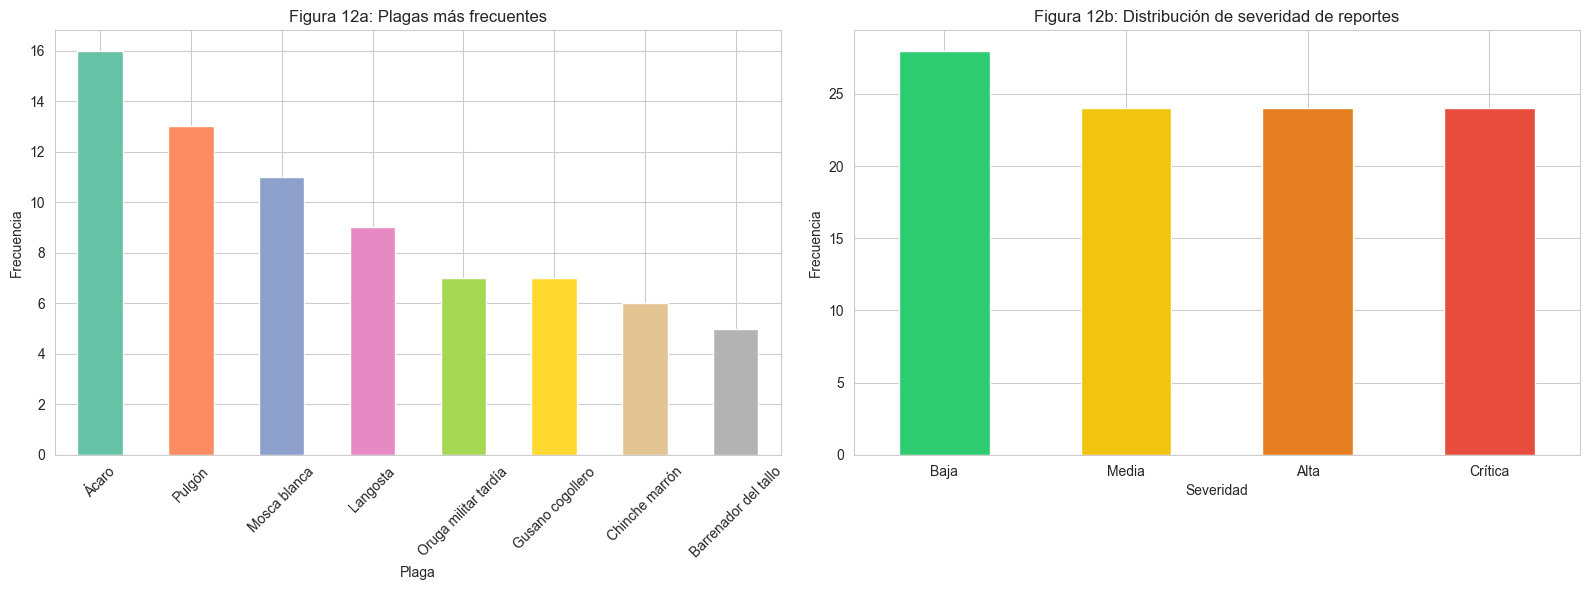

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plagas = reportes_plagas[reportes_plagas["Plaga detectada"] != "Desconocido"]
plagas_freq = plagas["Plaga detectada"].value_counts()
plagas_freq.plot(kind="bar", ax=axes[0], color=sns.color_palette("Set2"))
axes[0].set_xlabel("Plaga")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Figura 12a: Plagas más frecuentes")
axes[0].tick_params(axis='x', rotation=45)

severidad_orden = ["Baja", "Media", "Alta", "Crítica"]
sev_counts = reportes_plagas["Severidad"].value_counts().reindex(severidad_orden)
colores_sev = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]
sev_counts.plot(kind="bar", ax=axes[1], color=colores_sev)
axes[1].set_xlabel("Severidad")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Figura 12b: Distribución de severidad de reportes")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
fig.savefig("../docs/figuras/fig12_plagas_severidad.png", bbox_inches="tight")
plt.show()

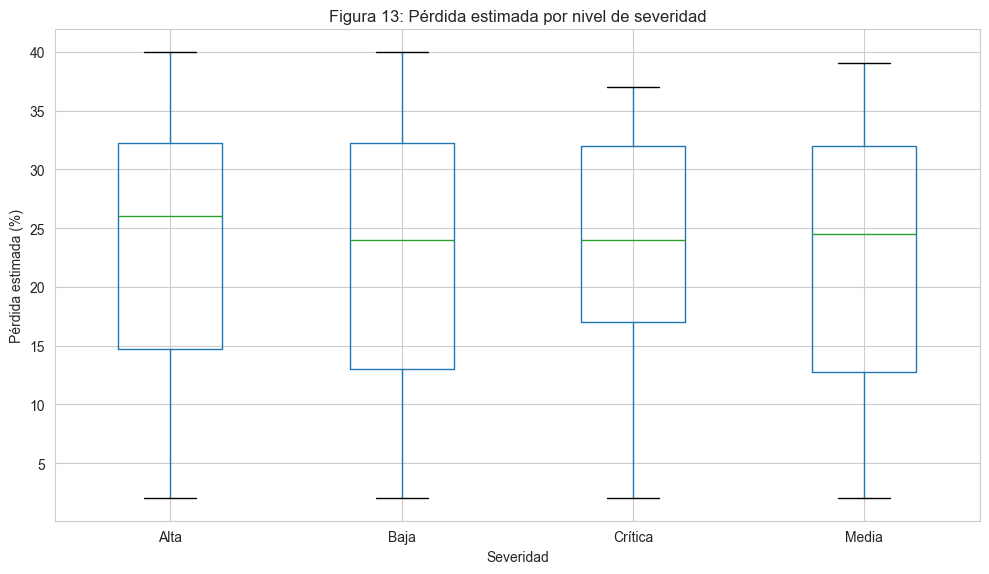

In [25]:
reportes_plagas["perdida_pct"] = reportes_plagas["Pérdida estimada"].str.replace("%", "").astype(float)

fig, ax = plt.subplots(figsize=(10, 6))
reportes_plagas.boxplot(column="perdida_pct", by="Severidad", ax=ax,
                        positions=[severidad_orden.index(s) for s in severidad_orden if s in reportes_plagas["Severidad"].unique()])
ax.set_xlabel("Severidad")
ax.set_ylabel("Pérdida estimada (%)")
ax.set_title("Figura 13: Pérdida estimada por nivel de severidad")
plt.suptitle("")
plt.tight_layout()
fig.savefig("../docs/figuras/fig13_perdida_por_severidad.png", bbox_inches="tight")
plt.show()

## 2.7 Subsidios y Políticas Agrícolas

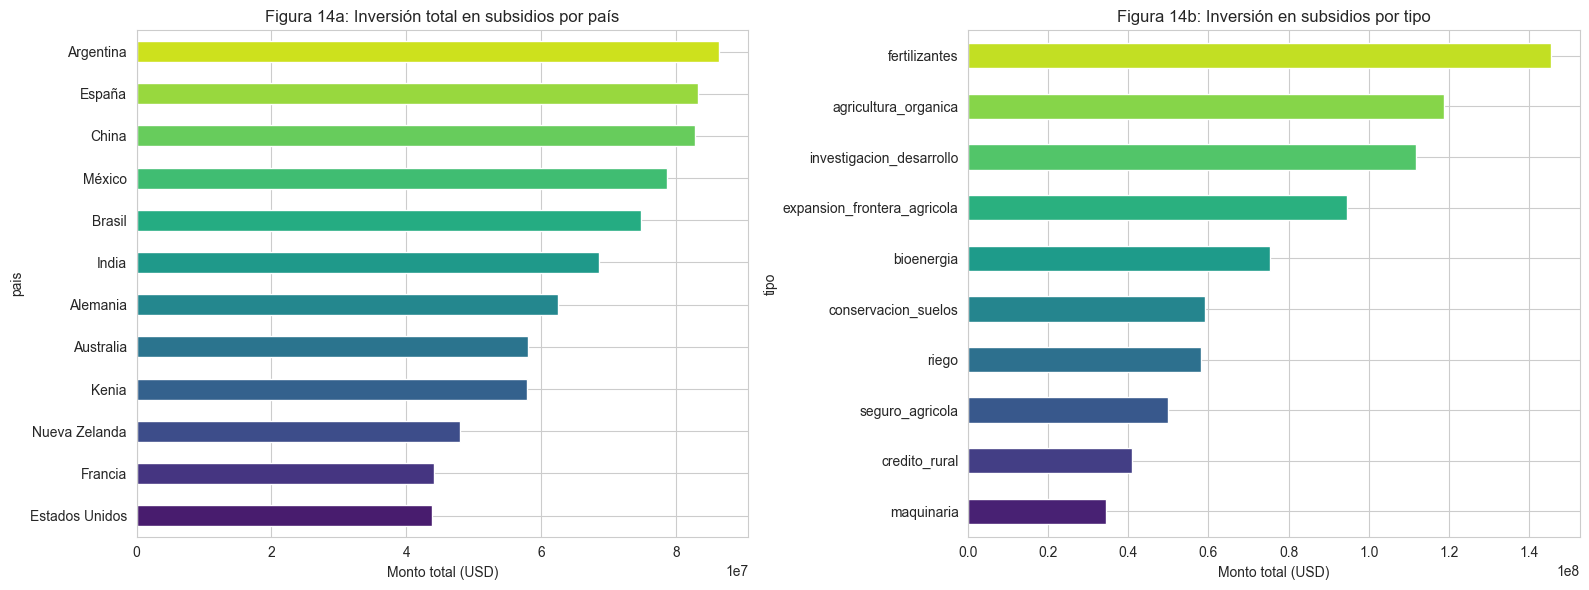

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sub_por_pais = subsidios.groupby("pais")["monto_usd"].sum().sort_values()
sub_por_pais.plot(kind="barh", ax=axes[0], color=sns.color_palette("viridis", len(sub_por_pais)))
axes[0].set_xlabel("Monto total (USD)")
axes[0].set_title("Figura 14a: Inversión total en subsidios por país")

sub_por_tipo = subsidios.groupby("tipo")["monto_usd"].sum().sort_values()
sub_por_tipo.plot(kind="barh", ax=axes[1], color=sns.color_palette("viridis", len(sub_por_tipo)))
axes[1].set_xlabel("Monto total (USD)")
axes[1].set_title("Figura 14b: Inversión en subsidios por tipo")

plt.tight_layout()
fig.savefig("../docs/figuras/fig14_subsidios.png", bbox_inches="tight")
plt.show()

## 2.8 Noticias Agrícolas - Análisis de texto

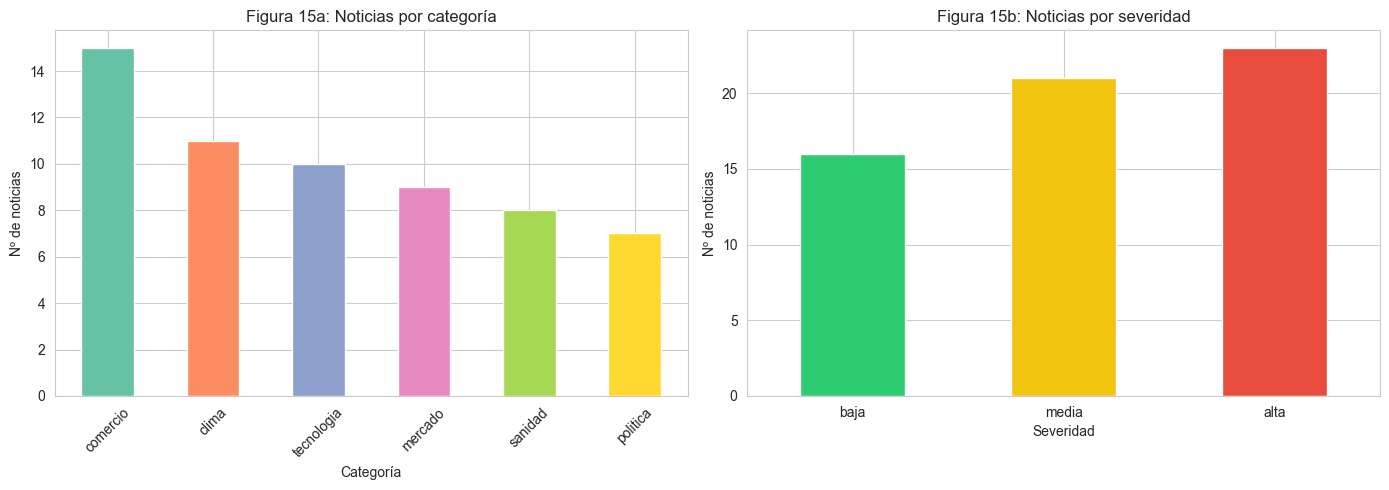

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

noticias_agricolas["categoria"].value_counts().plot(kind="bar", ax=axes[0], 
    color=sns.color_palette("Set2"))
axes[0].set_xlabel("Categoría")
axes[0].set_ylabel("Nº de noticias")
axes[0].set_title("Figura 15a: Noticias por categoría")
axes[0].tick_params(axis='x', rotation=45)

sev_noticias = noticias_agricolas["severidad"].value_counts().reindex(["baja", "media", "alta"])
sev_noticias.plot(kind="bar", ax=axes[1], color=["#2ecc71", "#f1c40f", "#e74c3c"])
axes[1].set_xlabel("Severidad")
axes[1].set_ylabel("Nº de noticias")
axes[1].set_title("Figura 15b: Noticias por severidad")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
fig.savefig("../docs/figuras/fig15_noticias.png", bbox_inches="tight")
plt.show()

## 2.9 Análisis cruzado - Relaciones entre datasets

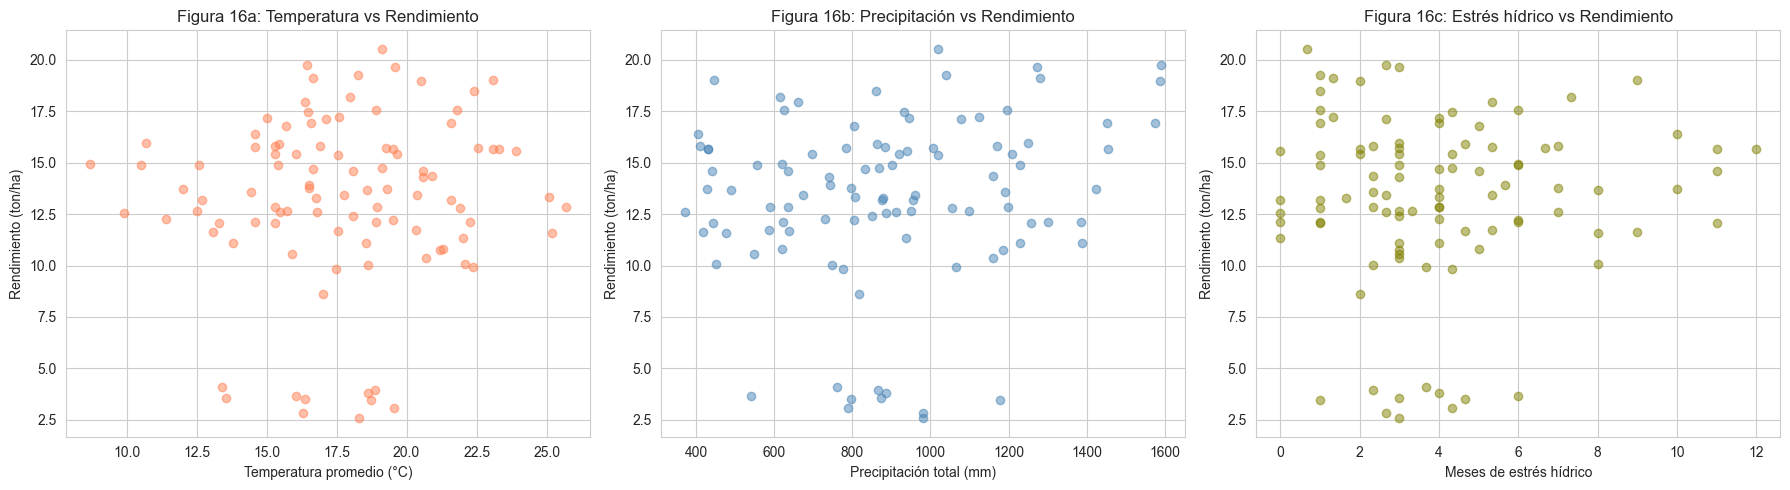

In [28]:
agricola_anio = produccion_agricola.copy()
agricola_anio["anio_num"] = agricola_anio["anio"].dt.year

clima_anio = condiciones_climaticas.copy()
clima_anio["anio_num"] = clima_anio["anio"].dt.year

rend_pais_anio = agricola_anio.groupby(["pais", "anio_num"])["rendimiento_ton_ha"].mean().reset_index()
clima_pais_anio = clima_anio.groupby(["pais", "anio_num"])[["temperatura_promedio", "precipitacion_total", "meses_estres_hidrico"]].mean().reset_index()

cruce = rend_pais_anio.merge(clima_pais_anio, on=["pais", "anio_num"], how="inner")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(cruce["temperatura_promedio"], cruce["rendimiento_ton_ha"], alpha=0.5, c="coral")
axes[0].set_xlabel("Temperatura promedio (°C)")
axes[0].set_ylabel("Rendimiento (ton/ha)")
axes[0].set_title("Figura 16a: Temperatura vs Rendimiento")

axes[1].scatter(cruce["precipitacion_total"], cruce["rendimiento_ton_ha"], alpha=0.5, c="steelblue")
axes[1].set_xlabel("Precipitación total (mm)")
axes[1].set_ylabel("Rendimiento (ton/ha)")
axes[1].set_title("Figura 16b: Precipitación vs Rendimiento")

axes[2].scatter(cruce["meses_estres_hidrico"], cruce["rendimiento_ton_ha"], alpha=0.5, c="olive")
axes[2].set_xlabel("Meses de estrés hídrico")
axes[2].set_ylabel("Rendimiento (ton/ha)")
axes[2].set_title("Figura 16c: Estrés hídrico vs Rendimiento")

plt.tight_layout()
fig.savefig("../docs/figuras/fig16_clima_vs_rendimiento.png", bbox_inches="tight")
plt.show()

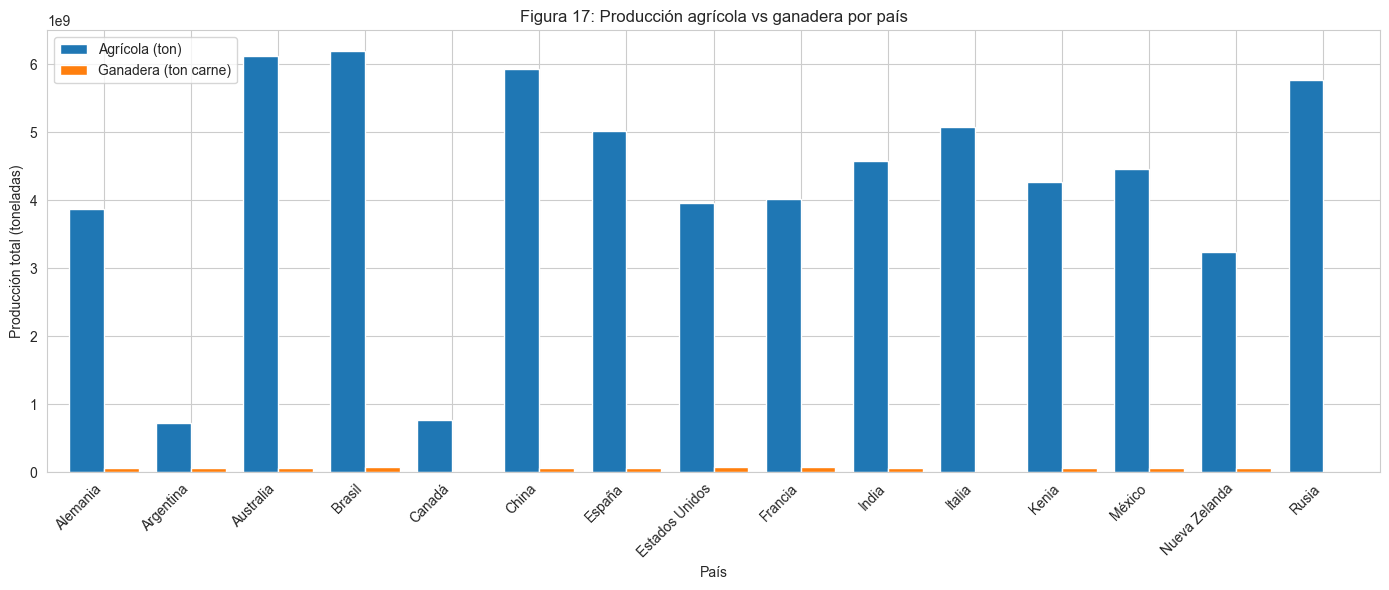

In [29]:
fig, ax = plt.subplots(figsize=(14, 6))

agri_total = produccion_agricola.groupby("pais")["produccion_ton"].sum()
gana_total = produccion_ganadera.groupby("pais")["produccion_carne_ton"].sum()

comparativa = pd.DataFrame({"Agrícola (ton)": agri_total, "Ganadera (ton carne)": gana_total}).fillna(0)

comparativa.plot(kind="bar", ax=ax, width=0.8)
ax.set_xlabel("País")
ax.set_ylabel("Producción total (toneladas)")
ax.set_title("Figura 17: Producción agrícola vs ganadera por país")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig("../docs/figuras/fig17_agricola_vs_ganadera.png", bbox_inches="tight")
plt.show()

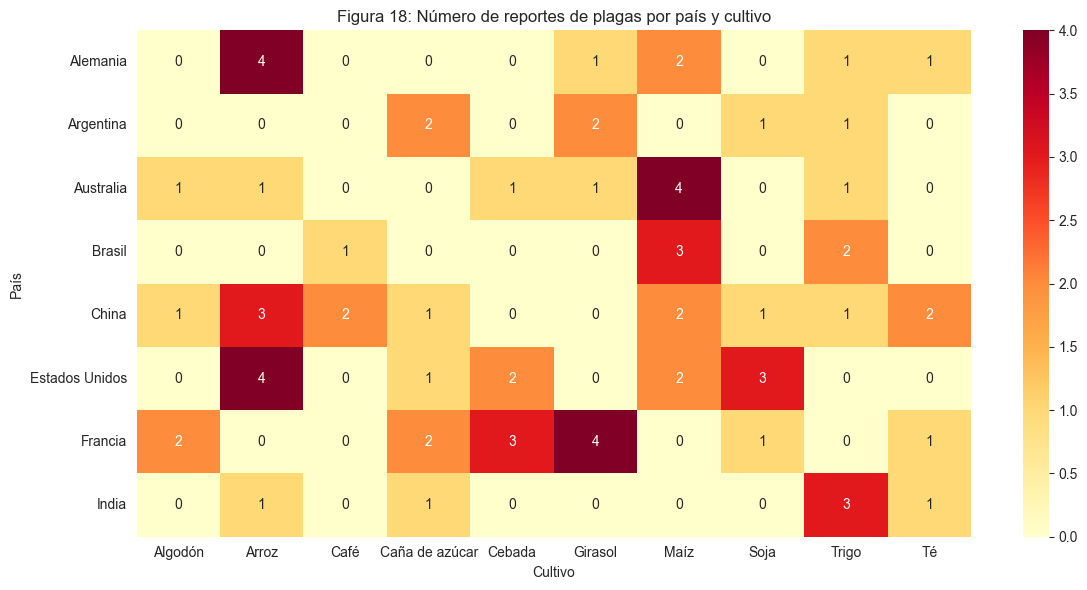

In [30]:
plagas_validas = reportes_plagas[reportes_plagas["Plaga detectada"] != "Desconocido"]
pivot_plagas = plagas_validas.pivot_table(index="País", columns="Cultivo", values="Plaga detectada", aggfunc="count").fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_plagas, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax)
ax.set_title("Figura 18: Número de reportes de plagas por país y cultivo")
plt.tight_layout()
fig.savefig("../docs/figuras/fig18_plagas_pais_cultivo.png", bbox_inches="tight")
plt.show()

# 3. Machine Learning

Esta sección aborda tres problemas de aprendizaje automático sobre el dominio agrícola-ganadero:

- **Problema 1**: Predicción de rendimiento agrícola (regresión supervisada)
- **Problema 2**: Clasificación del riesgo de plagas (clasificación supervisada)
- **Problema 3**: Segmentación de países por patrones productivos (clustering no supervisado)

In [31]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, label_binarize
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    roc_auc_score, roc_curve, silhouette_score
)
import xgboost as xgb
import shap


## 3.1 Problema 1: Predicción de Rendimiento Agrícola (Regresión)

**Objetivo**: Predecir el rendimiento (ton/ha) de cada cultivo a partir de variables agronómicas y climáticas.

**Variables**: superficie, fertilizantes, riego, tendencia, temperatura, precipitación, estrés hídrico, aridez, heladas, cultivo (enc.) y región (enc.).

**Modelos**: Random Forest · XGBoost  
**Métricas**: RMSE, MAE, R²

**Preparación** — merge agrícola + clima, encoding de cultivo y región

In [32]:
agricola_ml = produccion_agricola.copy()
agricola_ml['anio_num'] = agricola_ml['anio'].dt.year

clima_ml = condiciones_climaticas.copy()
clima_ml['anio_num'] = clima_ml['anio'].dt.year

clima_agg = clima_ml.groupby(['pais', 'anio_num']).agg(
    temperatura_promedio=('temperatura_promedio', 'mean'),
    precipitacion_total=('precipitacion_total', 'mean'),
    meses_estres_hidrico=('meses_estres_hidrico', 'mean'),
    indice_aridez=('indice_aridez', 'mean'),
    dias_con_heladas=('dias_con_heladas', 'mean')
).reset_index()

df_reg = agricola_ml.merge(clima_agg, on=['pais', 'anio_num'], how='left')

le_cultivo_r = LabelEncoder()
le_region_r  = LabelEncoder()
df_reg['cultivo_enc'] = le_cultivo_r.fit_transform(df_reg['cultivo'])
df_reg['region_enc']  = le_region_r.fit_transform(df_reg['region'])

FEATURES_REG = ['superficie_hectareas', 'fertilizantes_kg_ha', 'agua_riego_m3_ha',
                'tendencia_5_anios', 'temperatura_promedio', 'precipitacion_total',
                'meses_estres_hidrico', 'indice_aridez', 'dias_con_heladas',
                'cultivo_enc', 'region_enc']
TARGET_REG = 'rendimiento_ton_ha'

df_reg_clean = df_reg[FEATURES_REG + [TARGET_REG]].dropna()
X_r = df_reg_clean[FEATURES_REG]
y_r = df_reg_clean[TARGET_REG]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)


**Random Forest** — 200 árboles, max_depth=15

In [33]:
rf_r = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=2,
                              random_state=42, n_jobs=-1)
rf_r.fit(X_train_r, y_train_r)
y_pred_rf_r = rf_r.predict(X_test_r)


**XGBoost** — 200 iteraciones, learning_rate=0.05

In [34]:
xgb_r = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=42, n_jobs=-1)
xgb_r.fit(X_train_r, y_train_r)
y_pred_xgb_r = xgb_r.predict(X_test_r)


**Métricas** — RMSE, MAE, R²

In [35]:
def calc_reg_metrics(y_true, y_pred, nombre):
    return {
        'Modelo': nombre,
        'RMSE': round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        'MAE':  round(float(mean_absolute_error(y_true, y_pred)), 4),
        'R2':   round(float(r2_score(y_true, y_pred)), 4)
    }

metricas_reg = pd.DataFrame([
    calc_reg_metrics(y_test_r, y_pred_rf_r,  'Random Forest'),
    calc_reg_metrics(y_test_r, y_pred_xgb_r, 'XGBoost')
]).set_index('Modelo')
display(metricas_reg)


,RMSE,MAE,R2
Modelo,,,
Random Forest,8.3518,3.4425,0.9302
XGBoost,9.5732,4.7269,0.9083


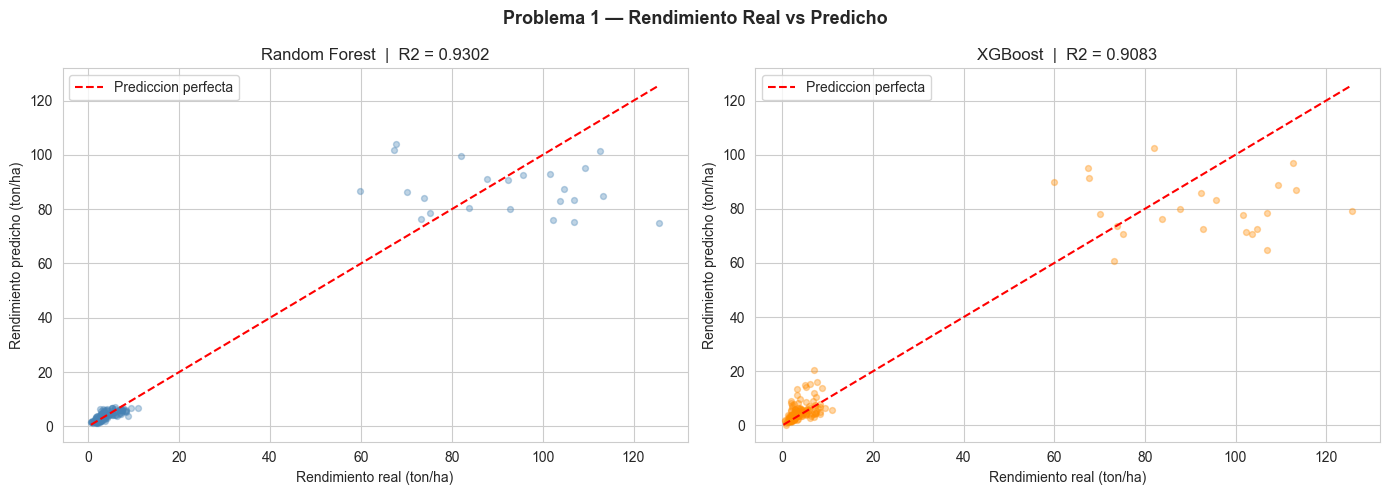

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, name, color in zip(
    axes,
    [y_pred_rf_r, y_pred_xgb_r],
    ['Random Forest', 'XGBoost'],
    ['steelblue', 'darkorange']
):
    ax.scatter(y_test_r, y_pred, alpha=0.35, s=18, color=color)
    lim_lo = min(float(y_test_r.min()), float(y_pred.min()))
    lim_hi = max(float(y_test_r.max()), float(y_pred.max()))
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'r--', linewidth=1.5, label='Prediccion perfecta')
    ax.set_xlabel('Rendimiento real (ton/ha)')
    ax.set_ylabel('Rendimiento predicho (ton/ha)')
    ax.set_title(f'{name}  |  R2 = {r2_score(y_test_r, y_pred):.4f}')
    ax.legend()

fig.suptitle('Problema 1 — Rendimiento Real vs Predicho', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig19_reg_predicciones_vs_real.png', bbox_inches='tight')
plt.show()


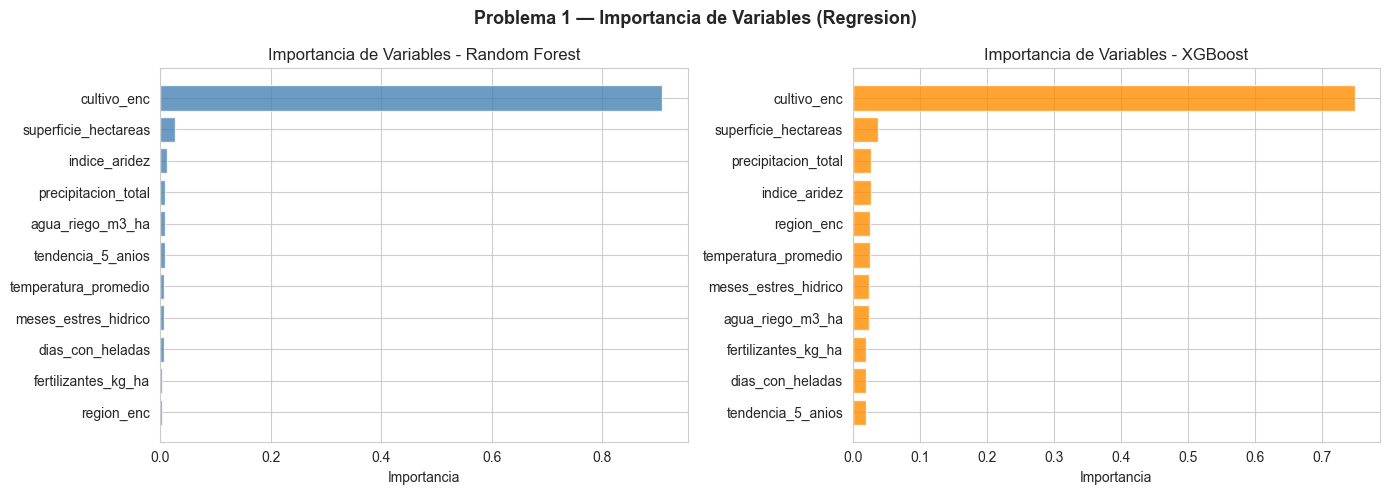

In [37]:
imp_rf_r  = pd.Series(rf_r.feature_importances_,  index=FEATURES_REG).sort_values()
imp_xgb_r = pd.Series(xgb_r.feature_importances_, index=FEATURES_REG).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, imp, name, color in zip(
    axes,
    [imp_rf_r, imp_xgb_r],
    ['Random Forest', 'XGBoost'],
    ['steelblue', 'darkorange']
):
    ax.barh(imp.index, imp.values, color=color, alpha=0.8)
    ax.set_xlabel('Importancia')
    ax.set_title(f'Importancia de Variables - {name}')

fig.suptitle('Problema 1 — Importancia de Variables (Regresion)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig20_reg_feature_importance.png', bbox_inches='tight')
plt.show()


## 3.2 Problema 2: Clasificación del Riesgo de Plagas

**Objetivo**: Predecir la severidad de una plaga (Baja / Media / Alta / Crítica) a partir de características del cultivo, tratamiento, área afectada y eficacia.

**Variables**: cultivo, plaga, región, tratamiento (enc.), área afectada (ha), eficacia (%), pérdida (%).

**Modelos**: Random Forest · XGBoost  
**Métricas**: Accuracy, F1-weighted, Matriz de Confusión, AUC-ROC

**Preparación** — parseo de columnas numéricas y target binario (Riesgo Alto vs Bajo)

In [38]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

plagas_ml = reportes_plagas.copy()
plagas_ml['area_ha']      = plagas_ml['Área afectada'].str.replace('ha', '', regex=False).str.strip().astype(float)
plagas_ml['eficacia_pct'] = plagas_ml['Eficacia'].str.replace('%', '', regex=False).str.strip().astype(float)
plagas_ml['perdida_pct']  = plagas_ml['Pérdida estimada'].str.replace('%', '', regex=False).str.strip().astype(float)

plagas_ml['riesgo_alto'] = plagas_ml['Severidad'].isin(['Alta', 'Crítica']).astype(int)

le_cult_c = LabelEncoder()
le_plag_c = LabelEncoder()
le_reg_c  = LabelEncoder()
le_trat_c = LabelEncoder()

plagas_ml['cultivo_enc'] = le_cult_c.fit_transform(plagas_ml['Cultivo'].astype(str))
plagas_ml['plaga_enc']   = le_plag_c.fit_transform(plagas_ml['Plaga detectada'].astype(str))
plagas_ml['region_enc']  = le_reg_c.fit_transform(plagas_ml['Región'].astype(str))
plagas_ml['trat_enc']    = le_trat_c.fit_transform(plagas_ml['Tratamiento aplicado'].astype(str))

FEATURES_CLF = ['cultivo_enc', 'plaga_enc', 'region_enc', 'trat_enc',
                'area_ha', 'eficacia_pct', 'perdida_pct']
TARGET_CLF = 'riesgo_alto'

df_clf = plagas_ml[FEATURES_CLF + [TARGET_CLF]].dropna()
X_c = df_clf[FEATURES_CLF]
y_c = df_clf[TARGET_CLF].astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

CLASS_NAMES = ['Riesgo Bajo', 'Riesgo Alto']


**Random Forest** — class_weight=balanced (mitiga desbalance)

In [39]:
rf_c = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2,
                               class_weight='balanced', random_state=42, n_jobs=-1)
rf_c.fit(X_train_c, y_train_c)
y_pred_rf_c = rf_c.predict(X_test_c)


**XGBoost** — eval_metric=logloss

In [40]:
xgb_c = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_c.fit(X_train_c, y_train_c)
y_pred_xgb_c = xgb_c.predict(X_test_c)


**Métricas + Cross-Validation 5-fold** (F1) para evaluación robusta

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_cv_rf  = cross_val_score(rf_c,  X_c, y_c, cv=cv, scoring='f1', n_jobs=-1)
f1_cv_xgb = cross_val_score(xgb_c, X_c, y_c, cv=cv, scoring='f1', n_jobs=-1)

metricas_clf = pd.DataFrame({
    'Random Forest': {
        'Accuracy':        round(accuracy_score(y_test_c, y_pred_rf_c), 4),
        'F1':              round(f1_score(y_test_c, y_pred_rf_c), 4),
        'CV-F1 (media)':   round(float(f1_cv_rf.mean()), 4),
        'CV-F1 (std)':     round(float(f1_cv_rf.std()), 4),
    },
    'XGBoost': {
        'Accuracy':        round(accuracy_score(y_test_c, y_pred_xgb_c), 4),
        'F1':              round(f1_score(y_test_c, y_pred_xgb_c), 4),
        'CV-F1 (media)':   round(float(f1_cv_xgb.mean()), 4),
        'CV-F1 (std)':     round(float(f1_cv_xgb.std()), 4),
    }
}).T
display(metricas_clf)

clf_report = pd.DataFrame(
    classification_report(y_test_c, y_pred_xgb_c, target_names=CLASS_NAMES, output_dict=True)
).T.round(4)
display(clf_report)


,Accuracy,F1,CV-F1 (media),CV-F1 (std)
Random Forest,0.60,0.5000,0.4266,0.0995
XGBoost,0.65,0.5882,0.4023,0.0616


,precision,recall,f1-score,support
Riesgo Bajo,0.6154,0.80,0.6957,10.00
Riesgo Alto,0.7143,0.50,0.5882,10.00
accuracy,0.6500,0.65,0.6500,0.65
macro avg,0.6648,0.65,0.6419,20.00
weighted avg,0.6648,0.65,0.6419,20.00


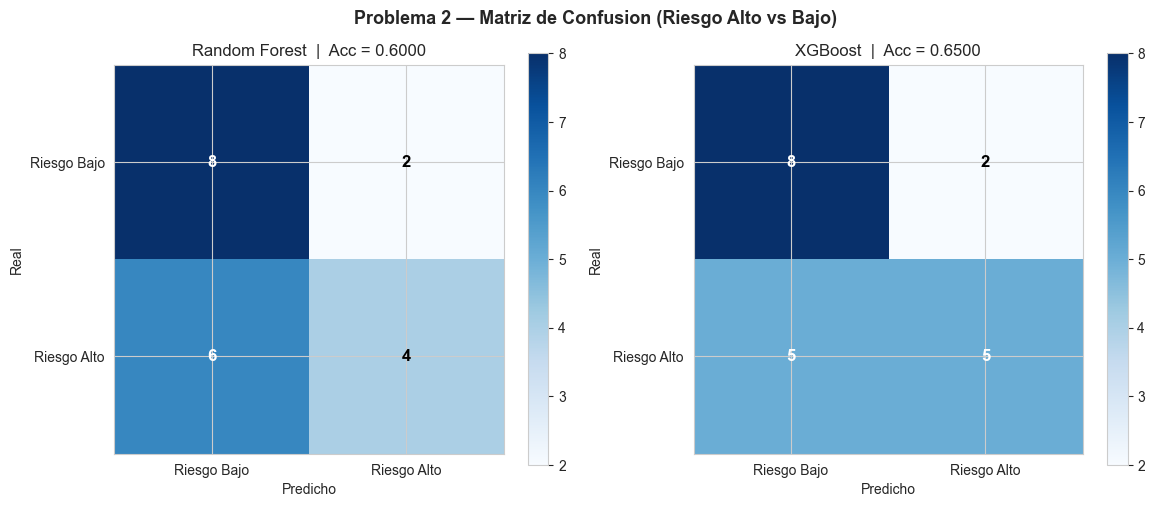

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, name in zip(axes, [y_pred_rf_c, y_pred_xgb_c], ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test_c, y_pred)
    im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(2))
    ax.set_yticks(range(2))
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticklabels(CLASS_NAMES)
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(f'{name}  |  Acc = {accuracy_score(y_test_c, y_pred):.4f}')

fig.suptitle('Problema 2 — Matriz de Confusion (Riesgo Alto vs Bajo)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig22_clf_confusion_matrix.png', bbox_inches='tight')
plt.show()


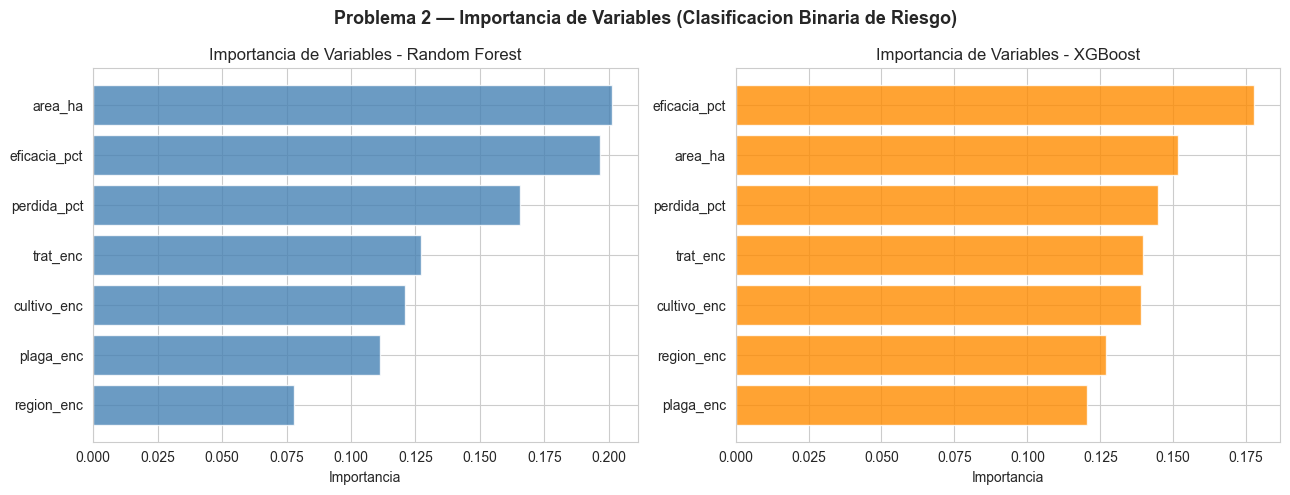

In [43]:
imp_rf_c  = pd.Series(rf_c.feature_importances_,  index=FEATURES_CLF).sort_values()
imp_xgb_c = pd.Series(xgb_c.feature_importances_, index=FEATURES_CLF).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, imp, name, color in zip(
    axes, [imp_rf_c, imp_xgb_c], ['Random Forest', 'XGBoost'],
    ['steelblue', 'darkorange']
):
    ax.barh(imp.index, imp.values, color=color, alpha=0.8)
    ax.set_xlabel('Importancia')
    ax.set_title(f'Importancia de Variables - {name}')

fig.suptitle('Problema 2 — Importancia de Variables (Clasificacion Binaria de Riesgo)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig23_clf_feature_importance.png', bbox_inches='tight')
plt.show()


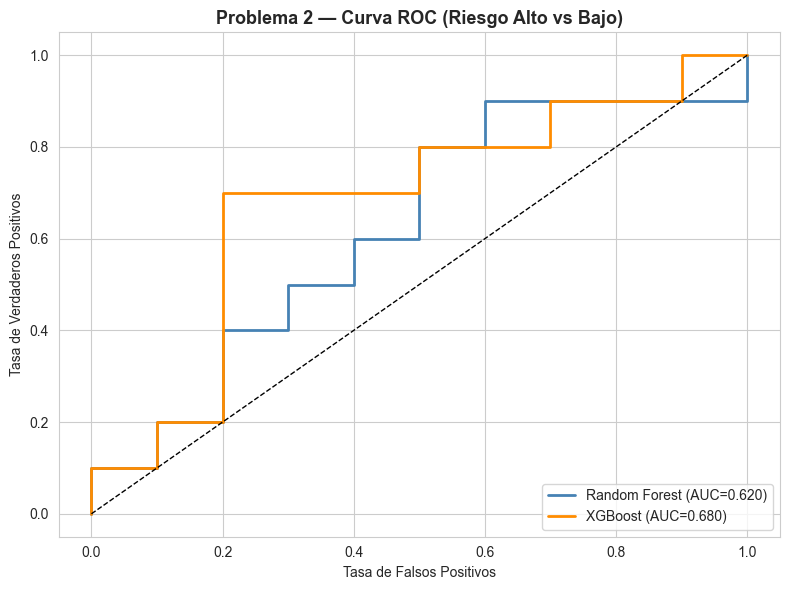

In [44]:
from sklearn.metrics import roc_curve, auc

y_prob_rf_c  = rf_c.predict_proba(X_test_c)[:, 1]
y_prob_xgb_c = xgb_c.predict_proba(X_test_c)[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))

for y_prob, name, color in [
    (y_prob_rf_c,  'Random Forest', 'steelblue'),
    (y_prob_xgb_c, 'XGBoost',       'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test_c, y_prob)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Problema 2 — Curva ROC (Riesgo Alto vs Bajo)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
fig.savefig('../docs/figuras/fig24_clf_roc_curves.png', bbox_inches='tight')
plt.show()


## 3.3 Problema 3: Segmentación de Países por Patrones Productivos (Clustering)

**Objetivo**: Agrupar países con perfiles productivos similares para identificar arquetipos de sistemas agrícola-ganaderos a escala global.

**Variables**: rendimiento medio, producción total, superficie, fertilizantes, riego, diversidad de cultivos, carne, leche, emisiones, eficiencia cárnica.

**Algoritmo**: K-Means (K elegido por Silhouette Score)  
**Métricas**: Silhouette Score, visualización PCA

**Preparación** — agregación por país (agrícola + ganadera) con log-transform en variables sesgadas

In [45]:
agricola_pais = produccion_agricola.groupby('pais').agg(
    rendimiento_medio=('rendimiento_ton_ha', 'mean'),
    produccion_total=('produccion_ton', 'sum'),
    superficie_media=('superficie_hectareas', 'mean'),
    fertilizantes_medio=('fertilizantes_kg_ha', 'mean'),
    agua_riego_media=('agua_riego_m3_ha', 'mean'),
    n_cultivos=('cultivo', 'nunique')
).reset_index()

ganadera_pais = produccion_ganadera.groupby('pais').agg(
    carne_total=('produccion_carne_ton', 'sum'),
    leche_total=('produccion_leche_lt', 'sum'),
    emisiones_media=('emisiones_ch4_ton_co2eq', 'mean'),
    eficiencia_media=('eficiencia_carne', 'mean')
).reset_index()

df_clust = agricola_pais.merge(ganadera_pais, on='pais', how='inner').dropna()

for col in ['produccion_total', 'carne_total', 'leche_total', 'emisiones_media']:
    df_clust[col + '_log'] = np.log1p(df_clust[col])

FEATURES_CLUST = ['rendimiento_medio', 'produccion_total_log', 'superficie_media',
                   'fertilizantes_medio', 'agua_riego_media', 'n_cultivos',
                   'carne_total_log', 'leche_total_log', 'emisiones_media_log',
                   'eficiencia_media']

scaler_cl = StandardScaler()
X_clust_sc = scaler_cl.fit_transform(df_clust[FEATURES_CLUST])


**Búsqueda del K óptimo** — Inercia (codo) + Silhouette Score

In [46]:
K_RANGE = range(2, 8)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust_sc, km.labels_))

best_k = list(K_RANGE)[int(np.argmax(silhouettes))]


**K-Means final** con K óptimo seleccionado

In [47]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_final.fit(X_clust_sc)
df_clust = df_clust.copy()
df_clust['cluster'] = km_final.labels_
sil_final = silhouette_score(X_clust_sc, km_final.labels_)

display(pd.DataFrame({'K optimo': [best_k], 'Silhouette Score': [round(sil_final, 4)]}))
display(df_clust.groupby('cluster')['pais'].apply(list).reset_index())


,K optimo,Silhouette Score
0,2,0.2959


,cluster,pais
0,0,"[Alemania, Australia, Brasil, China, España, E..."
1,1,[Argentina]


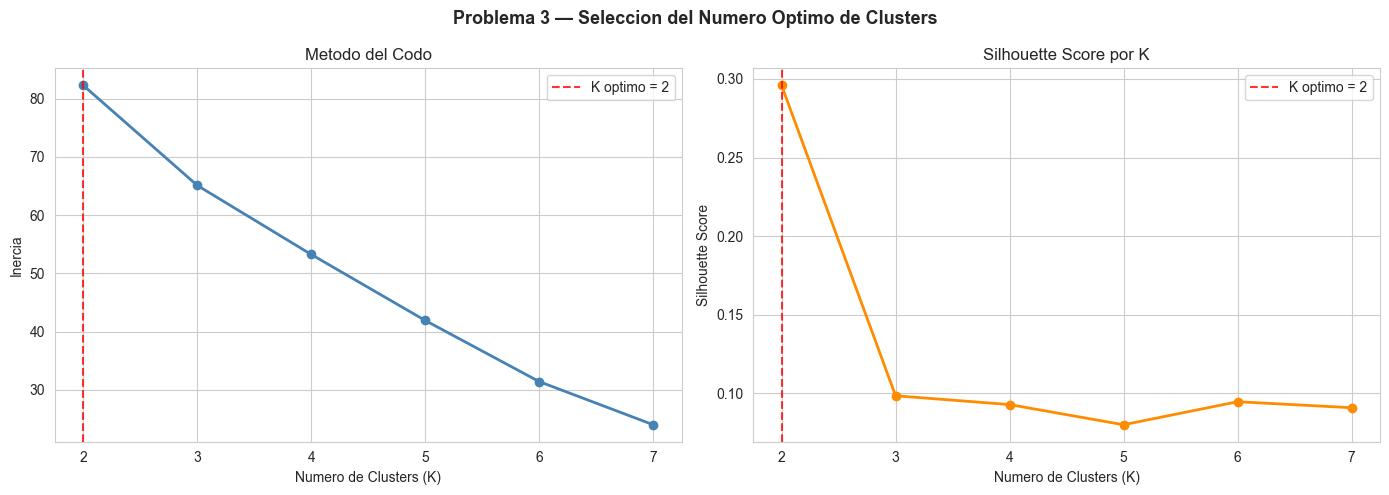

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=best_k, color='red', linestyle='--', alpha=0.8, label=f'K optimo = {best_k}')
axes[0].set_xlabel('Numero de Clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Metodo del Codo')
axes[0].legend()

axes[1].plot(list(K_RANGE), silhouettes, marker='o', color='darkorange', linewidth=2)
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.8, label=f'K optimo = {best_k}')
axes[1].set_xlabel('Numero de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K')
axes[1].legend()

fig.suptitle('Problema 3 — Seleccion del Numero Optimo de Clusters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig25_clust_elbow_silhouette.png', bbox_inches='tight')
plt.show()


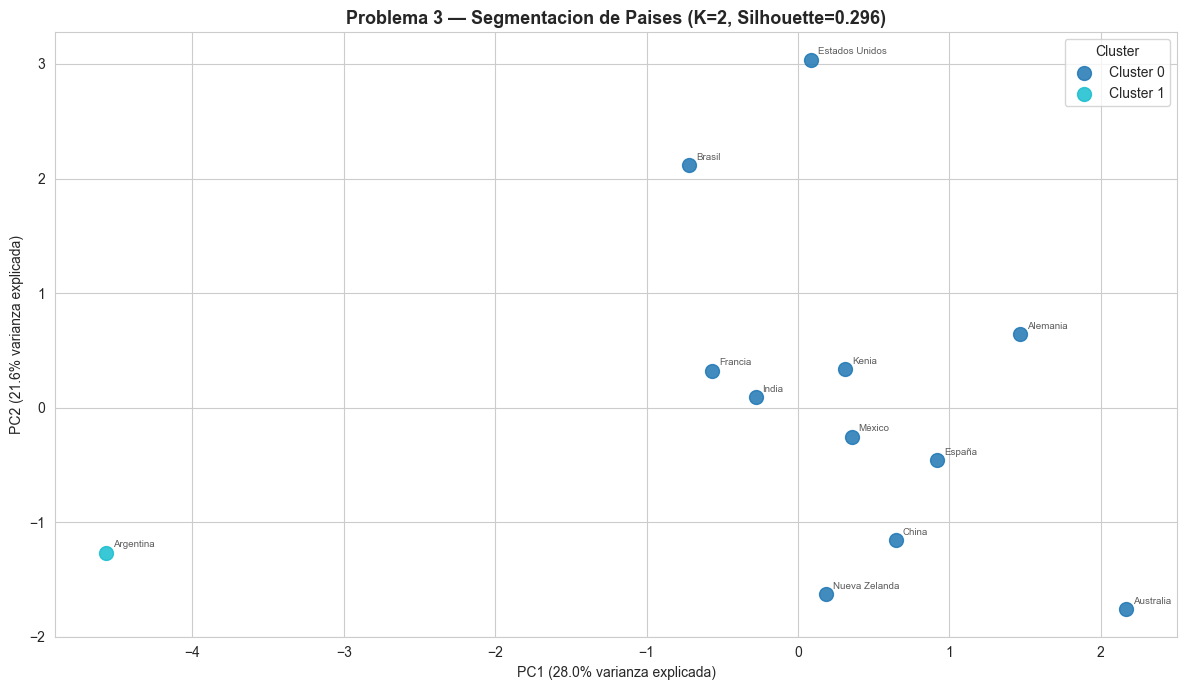

In [49]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_sc)
var_exp = pca.explained_variance_ratio_

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df_clust['cluster'].values
df_pca['pais']    = df_clust['pais'].values

palette = plt.cm.tab10(np.linspace(0, 0.9, best_k))

fig, ax = plt.subplots(figsize=(12, 7))

for i, clust in enumerate(sorted(df_pca['cluster'].unique())):
    mask = df_pca['cluster'] == clust
    ax.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
               label=f'Cluster {clust}', s=100, alpha=0.85, color=palette[i])

for _, row in df_pca.iterrows():
    ax.annotate(row['pais'], (row['PC1'], row['PC2']),
                textcoords='offset points', xytext=(5, 4), fontsize=7, alpha=0.75)

ax.set_xlabel(f'PC1 ({var_exp[0]:.1%} varianza explicada)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%} varianza explicada)')
ax.set_title(f'Problema 3 — Segmentacion de Paises (K={best_k}, Silhouette={sil_final:.3f})',
             fontsize=13, fontweight='bold')
ax.legend(title='Cluster', loc='best')
plt.tight_layout()
fig.savefig('../docs/figuras/fig26_clust_pca_scatter.png', bbox_inches='tight')
plt.show()


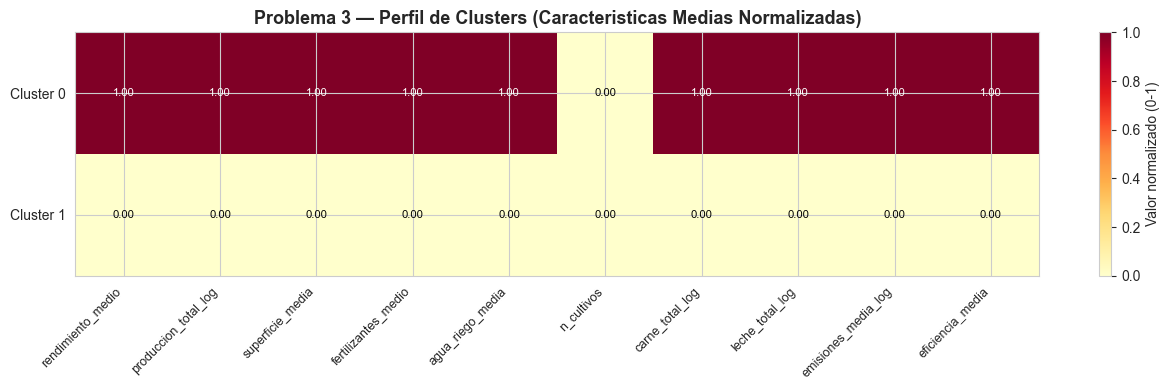

In [50]:
cluster_profiles = df_clust.groupby('cluster')[FEATURES_CLUST].mean()

mm = MinMaxScaler()
profiles_norm = pd.DataFrame(
    mm.fit_transform(cluster_profiles),
    index=cluster_profiles.index,
    columns=FEATURES_CLUST
)

fig, ax = plt.subplots(figsize=(13, max(4, best_k + 1)))
im = ax.imshow(profiles_norm.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Valor normalizado (0-1)')

ax.set_xticks(range(len(FEATURES_CLUST)))
ax.set_xticklabels(FEATURES_CLUST, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(best_k))
ax.set_yticklabels([f'Cluster {i}' for i in range(best_k)])

for i in range(best_k):
    for j in range(len(FEATURES_CLUST)):
        val = profiles_norm.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='black' if val < 0.65 else 'white')

ax.set_title('Problema 3 — Perfil de Clusters (Caracteristicas Medias Normalizadas)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig27_clust_profiles_heatmap.png', bbox_inches='tight')
plt.show()


## 3.4 Problema 4: Predicción de Precios de Mercado

**Objetivo**: Predecir la tendencia de precios (sube/baja/estable) y el precio futuro de productos agrícolas y ganaderos.

**Variables**: precios históricos, volumen operado, tendencia 30 días, producto, país.

**Modelos**: ARIMA/SARIMA (series temporales) · XGBoost (con features derivadas)

**Métricas**: MAE, MAPE, Directional Accuracy

**Preparación** — serie mensual de precios del Maíz en Brasil (resample + interpolación)

In [51]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

precios_ts = precios_mercado.copy()
precios_ts['fecha'] = pd.to_datetime(precios_ts['fecha'])
precios_ts = precios_ts.sort_values(['producto', 'pais', 'fecha'])

serie_ejemplo = precios_ts[
    (precios_ts['producto'] == 'Maíz') & (precios_ts['pais'] == 'Brasil')
].set_index('fecha')['precio_usd_ton'].sort_index()

serie_ejemplo = serie_ejemplo.resample('MS').mean().interpolate(method='linear')

n_train = int(len(serie_ejemplo) * 0.8)
train_ts = serie_ejemplo.iloc[:n_train]
test_ts  = serie_ejemplo.iloc[n_train:]


**ARIMA(2,1,2)** — modelo autorregresivo integrado

In [52]:
modelo_arima = ARIMA(train_ts, order=(2, 1, 2))
fit_arima = modelo_arima.fit()
pred_arima = fit_arima.forecast(steps=len(test_ts))
pred_arima.index = test_ts.index


c:\Users\Marcos_PC\Documents\TRABAJO_FINAL\Proyecto_Final\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**SARIMA** — ARIMA con estacionalidad anual (12 meses)

In [53]:
modelo_sarima = SARIMAX(train_ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                         enforce_stationarity=False, enforce_invertibility=False)
fit_sarima = modelo_sarima.fit(disp=False)
pred_sarima = fit_sarima.forecast(steps=len(test_ts))
pred_sarima.index = test_ts.index


**XGBoost** — con features temporales (lags 1-3, rolling mean/std)

In [54]:
def crear_features_ts(df_precio, lags=3):
    df = df_precio.copy().reset_index()
    df['mes'] = df['fecha'].dt.month
    df['anio'] = df['fecha'].dt.year
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df['precio_usd_ton'].shift(lag)
    df['rolling_mean_3'] = df['precio_usd_ton'].rolling(3).mean()
    df['rolling_std_3']  = df['precio_usd_ton'].rolling(3).std()
    return df.dropna()

serie_df = serie_ejemplo.reset_index()
serie_df.columns = ['fecha', 'precio_usd_ton']
df_feat = crear_features_ts(serie_df, lags=3)

FEAT_TS = ['mes', 'anio', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3']
n_tr_xgb = int(len(df_feat) * 0.8)
X_tr_ts = df_feat.iloc[:n_tr_xgb][FEAT_TS]
y_tr_ts = df_feat.iloc[:n_tr_xgb]['precio_usd_ton']
X_te_ts = df_feat.iloc[n_tr_xgb:][FEAT_TS]
y_te_ts = df_feat.iloc[n_tr_xgb:]['precio_usd_ton']

xgb_ts = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
xgb_ts.fit(X_tr_ts, y_tr_ts)
pred_xgb_ts = xgb_ts.predict(X_te_ts)


**Métricas** — MAE, MAPE, Directional Accuracy

In [55]:
def ts_metrics(y_true, y_pred, nombre):
    mae = mean_absolute_error(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true.values - y_pred) / y_true.values)) * 100)
    dir_real = np.diff(y_true.values)
    dir_pred = np.diff(y_pred) if hasattr(y_pred, '__len__') else np.diff(y_pred.values)
    da = float(np.mean(np.sign(dir_real) == np.sign(dir_pred)) * 100)
    return {'Modelo': nombre, 'MAE (USD)': round(mae, 2),
            'MAPE (%)': round(mape, 2), 'Dir. Accuracy (%)': round(da, 1)}

metricas_ts = pd.DataFrame([
    ts_metrics(test_ts, pred_arima.values, 'ARIMA(2,1,2)'),
    ts_metrics(test_ts, pred_sarima.values, 'SARIMA'),
    ts_metrics(y_te_ts, pred_xgb_ts, 'XGBoost')
]).set_index('Modelo')
display(metricas_ts)


,MAE (USD),MAPE (%),Dir. Accuracy (%)
Modelo,,,
"ARIMA(2,1,2)",7.94,3.72,25.0
SARIMA,22.68,10.74,50.0
XGBoost,13.88,6.56,66.7


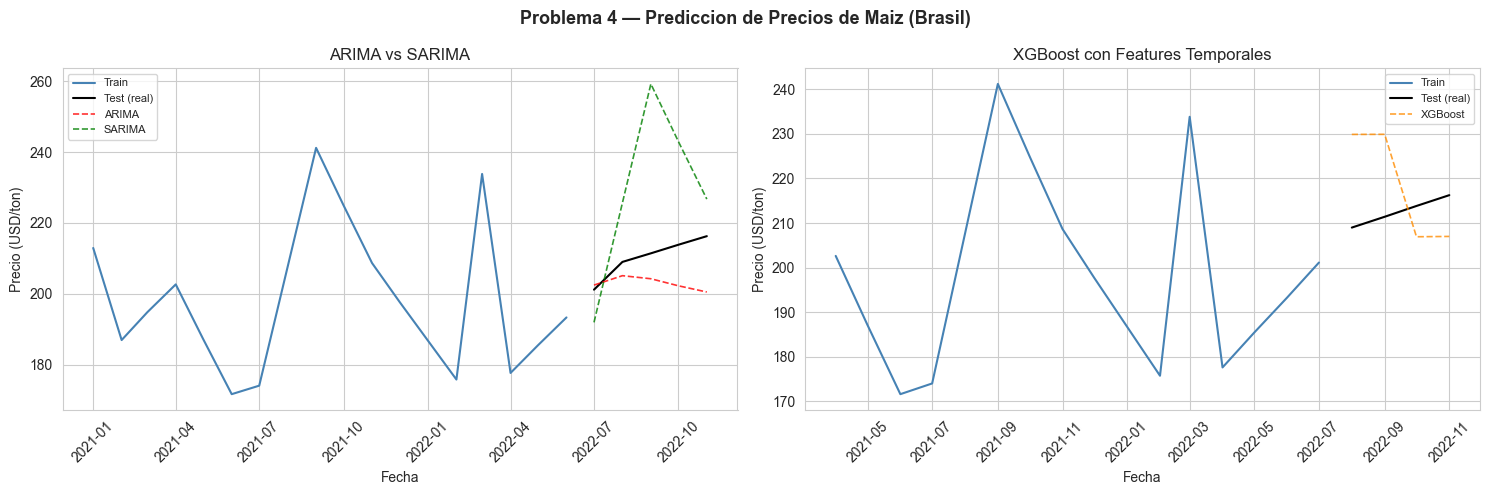

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Serie completa con predicciones
axes[0].plot(train_ts.index, train_ts.values, 'steelblue', linewidth=1.5, label='Train')
axes[0].plot(test_ts.index, test_ts.values, 'black', linewidth=1.5, label='Test (real)')
axes[0].plot(pred_arima.index, pred_arima.values, 'r--', linewidth=1.2, label='ARIMA', alpha=0.8)
axes[0].plot(pred_sarima.index, pred_sarima.values, 'g--', linewidth=1.2, label='SARIMA', alpha=0.8)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Precio (USD/ton)')
axes[0].set_title('ARIMA vs SARIMA')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

# XGBoost
fechas_xgb = df_feat.iloc[n_tr_xgb:]['fecha'].values
axes[1].plot(df_feat.iloc[:n_tr_xgb]['fecha'].values, y_tr_ts.values,
             'steelblue', linewidth=1.5, label='Train')
axes[1].plot(fechas_xgb, y_te_ts.values, 'black', linewidth=1.5, label='Test (real)')
axes[1].plot(fechas_xgb, pred_xgb_ts, 'darkorange', linestyle='--', linewidth=1.2,
             label='XGBoost', alpha=0.8)
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Precio (USD/ton)')
axes[1].set_title('XGBoost con Features Temporales')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

fig.suptitle('Problema 4 — Prediccion de Precios de Maiz (Brasil)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig28_ts_prediccion_precios.png', bbox_inches='tight')
plt.show()


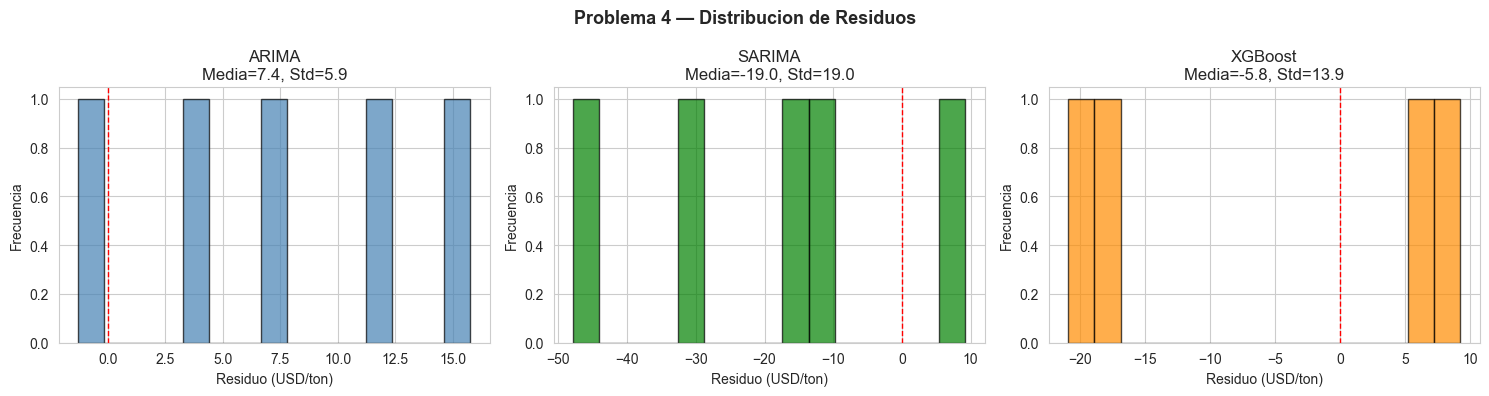

In [57]:
# Residuos y distribución de errores
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

residuos = {
    'ARIMA': test_ts.values - pred_arima.values,
    'SARIMA': test_ts.values - pred_sarima.values,
    'XGBoost': y_te_ts.values - pred_xgb_ts
}
colores = ['steelblue', 'green', 'darkorange']

for ax, (nombre, res), color in zip(axes, residuos.items(), colores):
    ax.hist(res, bins=15, color=color, alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Residuo (USD/ton)')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'{nombre}\nMedia={np.mean(res):.1f}, Std={np.std(res):.1f}')

fig.suptitle('Problema 4 — Distribucion de Residuos', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig29_ts_residuos.png', bbox_inches='tight')
plt.show()


## 3.5 Problema 5: Detección de Anomalías en Producción

**Objetivo**: Identificar años o regiones con comportamiento productivo anómalo.

**Variables**: rendimiento, producción, superficie, fertilizantes, riego.

**Modelos**: Z-score (básico) · Isolation Forest (intermedio)

**Métricas**: Número de anomalías detectadas, concordancia entre métodos

**Preparación** — selección de variables productivas para detección de outliers

In [58]:
from sklearn.ensemble import IsolationForest

anom_cols = ['rendimiento_ton_ha', 'produccion_ton', 'superficie_hectareas',
             'fertilizantes_kg_ha', 'agua_riego_m3_ha']

df_anom = produccion_agricola[['pais', 'cultivo', 'anio'] + anom_cols].copy()
df_anom['anio_num'] = df_anom['anio'].dt.year


**Método 1: Z-score** por cultivo (umbral |z| > 2.5)

In [59]:
for col in anom_cols:
    df_anom[f'z_{col}'] = df_anom.groupby('cultivo')[col].transform(
        lambda x: np.abs((x - x.mean()) / x.std()) if x.std() > 0 else 0
    )

z_cols = [f'z_{c}' for c in anom_cols]
df_anom['max_z'] = df_anom[z_cols].max(axis=1)
df_anom['anomalia_zscore'] = (df_anom['max_z'] > 2.5).astype(int)


**Método 2: Isolation Forest** (contamination=5%)

In [60]:
scaler_anom = StandardScaler()
df_anom_clean = df_anom.dropna(subset=anom_cols).copy()
X_anom = scaler_anom.fit_transform(df_anom_clean[anom_cols])

iso_forest = IsolationForest(n_estimators=200, contamination=0.05,
                              random_state=42, n_jobs=-1)
df_anom_clean['anomalia_iforest'] = iso_forest.fit_predict(X_anom)
df_anom_clean['anomalia_iforest'] = (df_anom_clean['anomalia_iforest'] == -1).astype(int)
df_anom_clean['score_iforest'] = iso_forest.score_samples(X_anom)


**Resultados** — concordancia entre ambos métodos

In [61]:
ambos = (df_anom_clean['anomalia_zscore'] == 1) & (df_anom_clean['anomalia_iforest'] == 1)

resumen_anom = pd.DataFrame({
    'Z-score (|z|>2.5)': [int(df_anom_clean['anomalia_zscore'].sum())],
    'Isolation Forest (5%)': [int(df_anom_clean['anomalia_iforest'].sum())],
    'Coinciden ambos': [int(ambos.sum())],
    'Total registros': [len(df_anom_clean)]
})
display(resumen_anom)

anomalias_conf = df_anom_clean[ambos][['pais', 'cultivo', 'anio_num'] + anom_cols]
if len(anomalias_conf) > 0:
    display(anomalias_conf.sort_values('rendimiento_ton_ha', ascending=False).head(15))


,Z-score (|z|>2.5),Isolation Forest (5%),Coinciden ambos,Total registros
0,26,60,7,1200


,pais,cultivo,anio_num,rendimiento_ton_ha,produccion_ton,superficie_hectareas,fertilizantes_kg_ha,agua_riego_m3_ha
1176,Rusia,Caña de azúcar,2018,158.45,481787490,3040637,80,7899
86,Brasil,Caña de azúcar,2011,125.62,1117450621,8895477,125,4727
330,China,Caña de azúcar,2012,123.63,1125569194,9104123,192,3733
338,China,Caña de azúcar,2013,119.82,1154381363,9634196,159,3719
110,Brasil,Caña de azúcar,2014,106.85,1134706673,10620028,187,8935
707,México,Caña de azúcar,2019,76.58,922178053,12041881,131,5440
1107,Canadá,Maíz,2019,6.36,80315674,12630627,252,1118


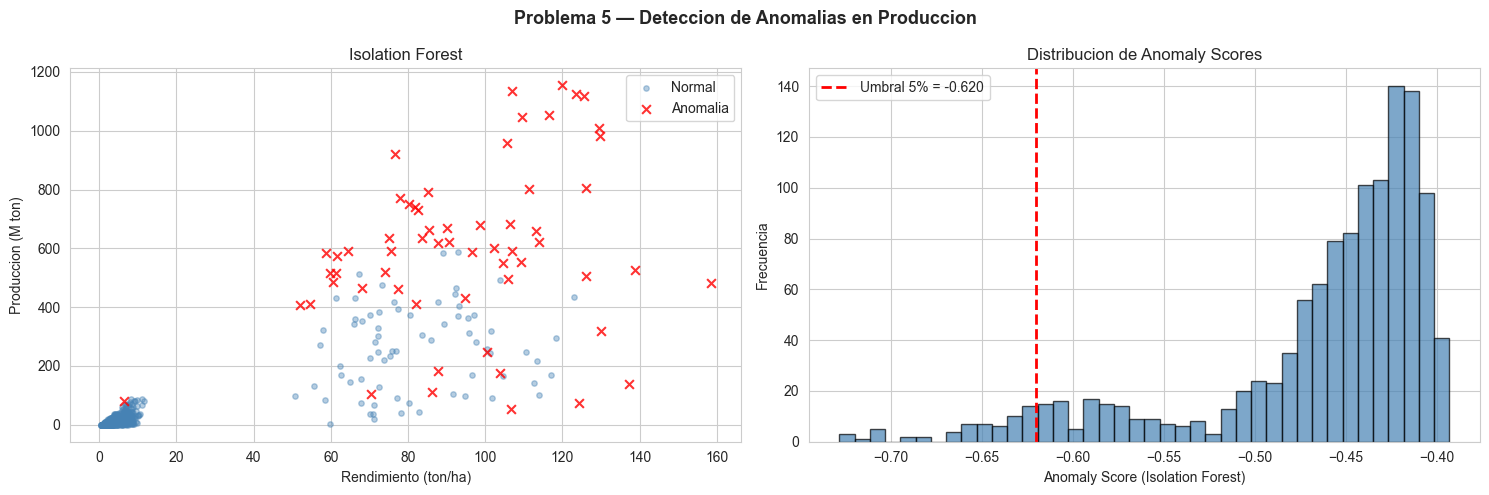

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: rendimiento vs producción, coloreado por anomalía IF
normal = df_anom_clean[df_anom_clean['anomalia_iforest'] == 0]
anomalo = df_anom_clean[df_anom_clean['anomalia_iforest'] == 1]

axes[0].scatter(normal['rendimiento_ton_ha'], normal['produccion_ton'] / 1e6,
                s=15, alpha=0.4, color='steelblue', label='Normal')
axes[0].scatter(anomalo['rendimiento_ton_ha'], anomalo['produccion_ton'] / 1e6,
                s=40, alpha=0.8, color='red', marker='x', label='Anomalia')
axes[0].set_xlabel('Rendimiento (ton/ha)')
axes[0].set_ylabel('Produccion (M ton)')
axes[0].set_title('Isolation Forest')
axes[0].legend()

# Distribución de anomaly scores
axes[1].hist(df_anom_clean['score_iforest'], bins=40, color='steelblue',
             alpha=0.7, edgecolor='black')
threshold_if = np.percentile(df_anom_clean['score_iforest'], 5)
axes[1].axvline(threshold_if, color='red', linestyle='--', linewidth=2,
                label=f'Umbral 5% = {threshold_if:.3f}')
axes[1].set_xlabel('Anomaly Score (Isolation Forest)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de Anomaly Scores')
axes[1].legend()

fig.suptitle('Problema 5 — Deteccion de Anomalias en Produccion',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig30_anomalias_scatter.png', bbox_inches='tight')
plt.show()


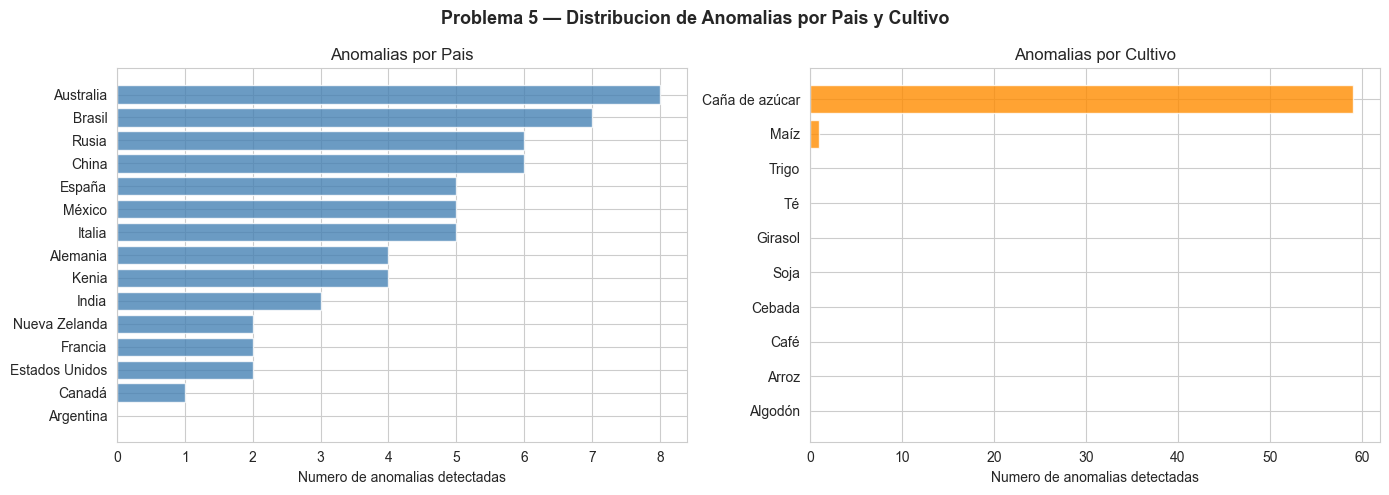

In [63]:
# Anomalías por país y cultivo
anom_pais = df_anom_clean.groupby('pais')['anomalia_iforest'].sum().sort_values(ascending=True)
anom_cult = df_anom_clean.groupby('cultivo')['anomalia_iforest'].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(anom_pais.index, anom_pais.values, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Numero de anomalias detectadas')
axes[0].set_title('Anomalias por Pais')

axes[1].barh(anom_cult.index, anom_cult.values, color='darkorange', alpha=0.8)
axes[1].set_xlabel('Numero de anomalias detectadas')
axes[1].set_title('Anomalias por Cultivo')

fig.suptitle('Problema 5 — Distribucion de Anomalias por Pais y Cultivo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig31_anomalias_por_grupo.png', bbox_inches='tight')
plt.show()


## 3.6 Problema 6: Recomendación de Cultivos

**Objetivo**: Recomendar el cultivo óptimo para una región dadas sus condiciones climáticas, de suelo y de mercado.

**Variables**: temperatura, precipitación, estrés hídrico, aridez, heladas, fertilizantes, riego, país, región.

**Modelos**: KNN · Decision Tree · Random Forest · XGBoost

**Métricas**: Accuracy, Top-3 Accuracy

**Preparación** — merge con condiciones climáticas y encoding

In [64]:
agr_rec = produccion_agricola.copy()
agr_rec['anio_num'] = agr_rec['anio'].dt.year

clim_rec = condiciones_climaticas.copy()
clim_rec['anio_num'] = clim_rec['anio'].dt.year
clim_agg_rec = clim_rec.groupby(['pais', 'anio_num']).agg(
    temp_prom=('temperatura_promedio', 'mean'),
    precip_total=('precipitacion_total', 'mean'),
    estres_hidrico=('meses_estres_hidrico', 'mean'),
    aridez=('indice_aridez', 'mean'),
    heladas=('dias_con_heladas', 'mean')
).reset_index()

df_rec = agr_rec.merge(clim_agg_rec, on=['pais', 'anio_num'], how='left')

le_pais_rec = LabelEncoder()
le_reg_rec  = LabelEncoder()
le_cult_rec = LabelEncoder()
df_rec['pais_enc']    = le_pais_rec.fit_transform(df_rec['pais'])
df_rec['region_enc']  = le_reg_rec.fit_transform(df_rec['region'])
df_rec['cultivo_enc'] = le_cult_rec.fit_transform(df_rec['cultivo'])
CULTIVOS_REC = list(le_cult_rec.classes_)

FEATURES_REC = ['pais_enc', 'region_enc', 'cultivo_enc',
                'fertilizantes_kg_ha', 'agua_riego_m3_ha',
                'temp_prom', 'precip_total', 'estres_hidrico', 'aridez', 'heladas']
TARGET_REC = 'rendimiento_ton_ha'

df_rec_clean = df_rec[FEATURES_REC + [TARGET_REC, 'pais', 'anio_num']].dropna()


**Split por (país, año)** — evita leakage entre train y test

In [65]:
combos = df_rec_clean[['pais', 'anio_num']].drop_duplicates().reset_index(drop=True)
combos_tr, combos_te = train_test_split(combos, test_size=0.2, random_state=42)
tr_keys = set(map(tuple, combos_tr.values))
te_keys = set(map(tuple, combos_te.values))

mask_tr = df_rec_clean.apply(lambda r: (r['pais'], r['anio_num']) in tr_keys, axis=1)
mask_te = df_rec_clean.apply(lambda r: (r['pais'], r['anio_num']) in te_keys, axis=1)
df_tr_rec = df_rec_clean[mask_tr]
df_te_rec = df_rec_clean[mask_te]

X_tr_rec = df_tr_rec[FEATURES_REC]
y_tr_rec = df_tr_rec[TARGET_REC]
X_te_rec = df_te_rec[FEATURES_REC]
y_te_rec = df_te_rec[TARGET_REC]


**Random Forest Regressor** — predice rendimiento variando el cultivo

In [66]:
reg_rec = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
reg_rec.fit(X_tr_rec, y_tr_rec)
y_pred_rec = reg_rec.predict(X_te_rec)
r2_rec = r2_score(y_te_rec, y_pred_rec)


**Evaluación por ranking** — Top-1 y Top-3 Accuracy sobre (país, año) de test

In [67]:
top1_hit = 0
top3_hit = 0
n_grp = 0
recomendaciones = []

for (pais_t, an_t), g in df_te_rec.groupby(['pais', 'anio_num']):
    if len(g) < 2:
        continue
    base_row = g.iloc[0][FEATURES_REC].copy()
    preds_c = {}
    for ce_val in range(len(CULTIVOS_REC)):
        row = base_row.copy()
        row['cultivo_enc'] = ce_val
        preds_c[ce_val] = float(reg_rec.predict(pd.DataFrame([row.values], columns=FEATURES_REC))[0])
    top3 = sorted(preds_c, key=preds_c.get, reverse=True)[:3]
    top1 = top3[0]
    real_best = int(g.loc[g[TARGET_REC].idxmax(), 'cultivo_enc'])
    if real_best == top1: top1_hit += 1
    if real_best in top3: top3_hit += 1
    recomendaciones.append({
        'pais': pais_t, 'anio': an_t,
        'recomendado_top1': CULTIVOS_REC[top1],
        'recomendado_top3': ', '.join([CULTIVOS_REC[c] for c in top3]),
        'real_top1': CULTIVOS_REC[real_best]
    })
    n_grp += 1

metricas_rec = pd.DataFrame({
    'Regresor (Random Forest)': {
        'R2 rendimiento': round(r2_rec, 4),
        'Top-1 Accuracy': round(top1_hit / n_grp, 4),
        'Top-3 Accuracy': round(top3_hit / n_grp, 4),
        'N grupos test': n_grp
    }
}).T
display(metricas_rec)

df_reco = pd.DataFrame(recomendaciones)
display(df_reco.head(10))


,R2 rendimiento,Top-1 Accuracy,Top-3 Accuracy,N grupos test
Regresor (Random Forest),0.9272,0.9,1.0,20.0


,pais,anio,recomendado_top1,recomendado_top3,real_top1
0,Argentina,2011,Caña de azúcar,"Caña de azúcar, Maíz, Arroz",Maíz
1,Argentina,2015,Caña de azúcar,"Caña de azúcar, Maíz, Arroz",Maíz
2,Australia,2011,Caña de azúcar,"Caña de azúcar, Arroz, Maíz",Caña de azúcar
3,Australia,2014,Caña de azúcar,"Caña de azúcar, Trigo, Maíz",Caña de azúcar
4,Australia,2017,Caña de azúcar,"Caña de azúcar, Maíz, Arroz",Caña de azúcar
5,Australia,2018,Caña de azúcar,"Caña de azúcar, Trigo, Maíz",Caña de azúcar
6,Brasil,2011,Caña de azúcar,"Caña de azúcar, Maíz, Trigo",Caña de azúcar
7,Brasil,2013,Caña de azúcar,"Caña de azúcar, Maíz, Arroz",Caña de azúcar
8,Brasil,2019,Caña de azúcar,"Caña de azúcar, Maíz, Arroz",Caña de azúcar
9,China,2015,Caña de azúcar,"Caña de azúcar, Maíz, Arroz",Caña de azúcar


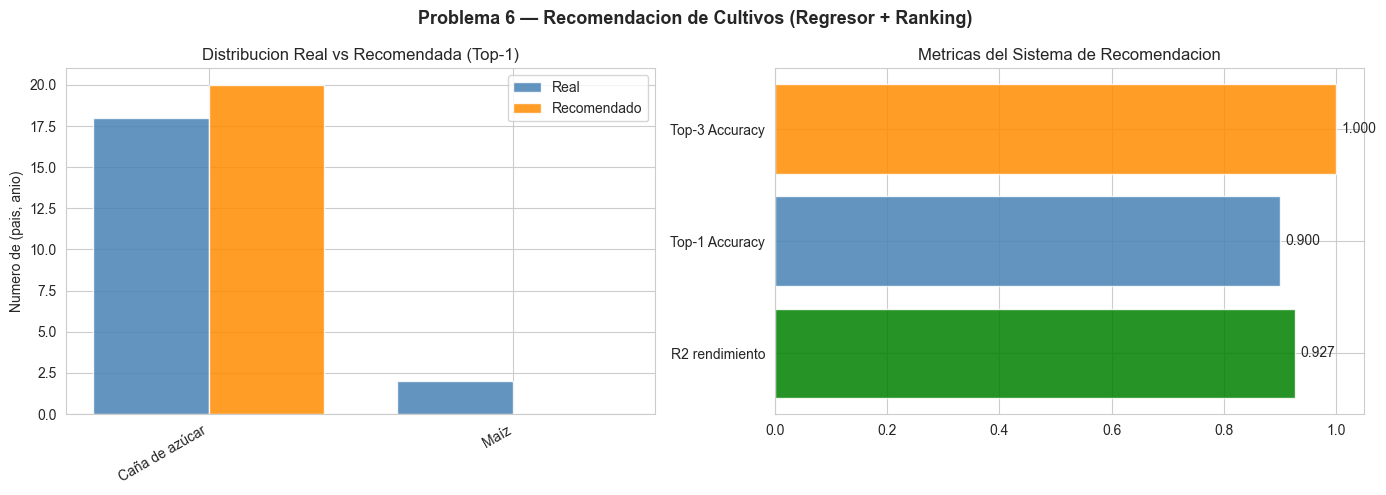

In [68]:
# Comparar distribución real vs recomendada de cultivos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

real_dist  = df_reco['real_top1'].value_counts()
reco_dist  = df_reco['recomendado_top1'].value_counts()
all_cult   = sorted(set(list(real_dist.index) + list(reco_dist.index)))
real_vals  = [real_dist.get(c, 0) for c in all_cult]
reco_vals  = [reco_dist.get(c, 0) for c in all_cult]

x = np.arange(len(all_cult))
w = 0.38
axes[0].bar(x - w/2, real_vals, w, color='steelblue',  label='Real',         alpha=0.85)
axes[0].bar(x + w/2, reco_vals, w, color='darkorange', label='Recomendado', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_cult, rotation=30, ha='right')
axes[0].set_ylabel('Numero de (pais, anio)')
axes[0].set_title('Distribucion Real vs Recomendada (Top-1)')
axes[0].legend()

# Barras con métricas top-1/top-3 y R2
metr = {
    'R2 rendimiento': r2_rec,
    'Top-1 Accuracy': top1_hit / n_grp,
    'Top-3 Accuracy': top3_hit / n_grp
}
axes[1].barh(list(metr.keys()), list(metr.values()),
             color=['green', 'steelblue', 'darkorange'], alpha=0.85)
axes[1].set_xlim(0, 1.05)
for i, v in enumerate(metr.values()):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)
axes[1].set_title('Metricas del Sistema de Recomendacion')

fig.suptitle('Problema 6 — Recomendacion de Cultivos (Regresor + Ranking)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig32_rec_confusion_comparativa.png', bbox_inches='tight')
plt.show()


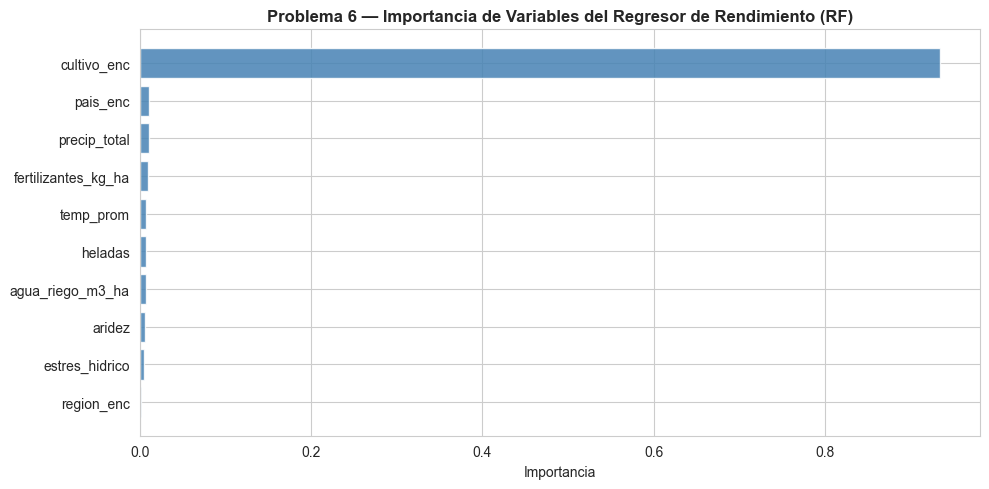

In [69]:
imp_reg = pd.Series(reg_rec.feature_importances_, index=FEATURES_REC).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(imp_reg.index, imp_reg.values, color='steelblue', alpha=0.85)
ax.set_xlabel('Importancia')
ax.set_title('Problema 6 — Importancia de Variables del Regresor de Rendimiento (RF)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig33_rec_feature_importance.png', bbox_inches='tight')
plt.show()


# 4. NLP — Análisis de Datos No Estructurados

Análisis del corpus de noticias agrícolas (`noticias_agricolas.jsonl`) usando técnicas de procesamiento de lenguaje natural: extracción de entidades, análisis de sentimiento, topic modeling y correlación con precios de mercado.

**Imports** — herramientas NLP de scikit-learn y regex

In [70]:
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Reutilizamos noticias_agricolas (cargado en la sección ETL)
nlp_corpus = noticias_agricolas.copy()
nlp_corpus['fecha'] = pd.to_datetime(nlp_corpus['fecha'])
nlp_corpus['texto_completo'] = nlp_corpus['titular'].fillna('') + '. ' + nlp_corpus['contenido'].fillna('')


**4.1 NER** — Extracción de entidades (cultivos, países, porcentajes)

In [71]:
CULTIVOS_NER = ['Trigo', 'Maíz', 'Arroz', 'Soja', 'Cebada', 'Caña de azúcar',
                 'Café', 'Algodón', 'Té', 'Girasol']
PAISES_NER = ['Argentina', 'Brasil', 'Australia', 'India', 'China', 'Francia',
               'Alemania', 'Estados Unidos', 'México', 'España', 'Kenia', 'Rusia',
               'Italia', 'Nueva Zelanda', 'Canadá']

def extraer_entidades(texto):
    t = texto.lower() if isinstance(texto, str) else ''
    cultivos = [c for c in CULTIVOS_NER if c.lower() in t]
    paises   = [p for p in PAISES_NER if p.lower() in t]
    porcentajes = re.findall(r'(\d+)\s*%', t)
    return cultivos, paises, [int(p) for p in porcentajes]

ents = nlp_corpus['texto_completo'].apply(extraer_entidades)
nlp_corpus['ner_cultivos'] = ents.apply(lambda x: x[0])
nlp_corpus['ner_paises']   = ents.apply(lambda x: x[1])
nlp_corpus['ner_pcts']     = ents.apply(lambda x: x[2])

# Frecuencias
from collections import Counter
freq_cultivos = Counter([c for lst in nlp_corpus['ner_cultivos'] for c in lst])
freq_paises   = Counter([p for lst in nlp_corpus['ner_paises']   for p in lst])
display(pd.DataFrame({
    'Top cultivos': [f'{c}: {n}' for c, n in freq_cultivos.most_common(5)],
    'Top paises':   [f'{p}: {n}' for p, n in freq_paises.most_common(5)]
}))


,Top cultivos,Top paises
0,Arroz: 5,China: 9
1,Maíz: 5,India: 7
2,Soja: 3,Italia: 7
3,Trigo: 3,Alemania: 6
4,Girasol: 2,Canadá: 5


**Figura: NER** — entidades más frecuentes en el corpus

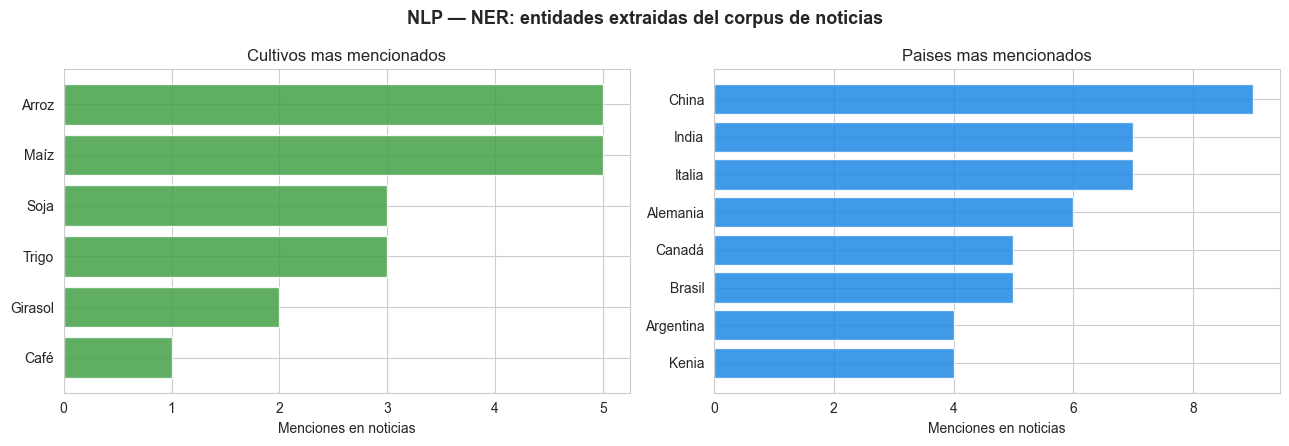

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

cult_top = freq_cultivos.most_common(8)
axes[0].barh([c for c,_ in cult_top][::-1], [n for _,n in cult_top][::-1],
             color='#43A047', alpha=0.85)
axes[0].set_xlabel('Menciones en noticias')
axes[0].set_title('Cultivos mas mencionados')

pais_top = freq_paises.most_common(8)
axes[1].barh([p for p,_ in pais_top][::-1], [n for _,n in pais_top][::-1],
             color='#1E88E5', alpha=0.85)
axes[1].set_xlabel('Menciones en noticias')
axes[1].set_title('Paises mas mencionados')

fig.suptitle('NLP — NER: entidades extraidas del corpus de noticias',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig34_nlp_ner.png', bbox_inches='tight')
plt.show()


**4.2 Análisis de Sentimiento** — léxico simple en español

In [73]:
POS_LEX = {'mejor','mejora','crece','aumenta','sube','sostenib','positivo','beneficio',
           'éxito','exito','recuperación','recuperacion','récord','record',
           'expansión','expansion','innovación','innovacion','optimist'}
NEG_LEX = {'reduce','pérdida','perdida','cae','baja','crisis','sequía','sequia',
           'plaga','extremo','daño','dano','caída','caida','amenaza','preocupa',
           'afecta','impacto negativo','escasez','colapso'}

def sentimiento(texto):
    t = texto.lower() if isinstance(texto, str) else ''
    pos = sum(1 for w in POS_LEX if w in t)
    neg = sum(1 for w in NEG_LEX if w in t)
    if pos + neg == 0:
        return 0.0
    return (pos - neg) / (pos + neg)

nlp_corpus['sentimiento'] = nlp_corpus['texto_completo'].apply(sentimiento)
nlp_corpus['sent_clase'] = pd.cut(nlp_corpus['sentimiento'],
                                   bins=[-1.01, -0.1, 0.1, 1.01],
                                   labels=['Negativo', 'Neutro', 'Positivo'])

resumen_sent = nlp_corpus.groupby('categoria').agg(
    n=('sentimiento', 'count'),
    sent_medio=('sentimiento', 'mean'),
    pct_negativo=('sent_clase', lambda x: (x == 'Negativo').mean() * 100)
).round(3)
display(resumen_sent)


,n,sent_medio,pct_negativo
categoria,,,
clima,11,-1.000,100.000
comercio,15,1.000,0.000
mercado,9,-0.333,55.556
politica,7,1.000,0.000
sanidad,8,1.000,0.000
tecnologia,10,1.000,0.000


**Figura: Sentimiento** — distribución por categoría

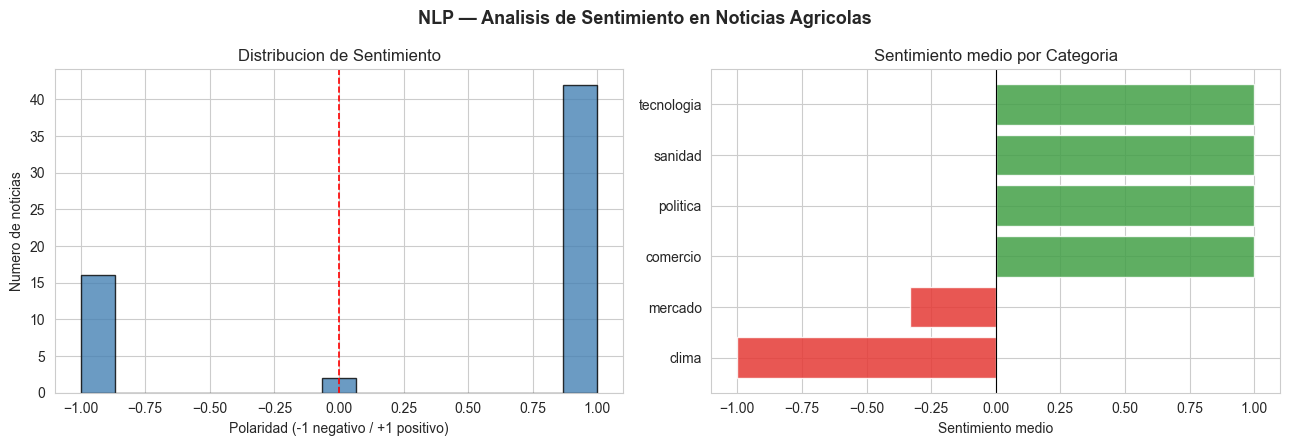

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribucion sentimiento
axes[0].hist(nlp_corpus['sentimiento'], bins=15, color='steelblue',
             alpha=0.8, edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_xlabel('Polaridad (-1 negativo / +1 positivo)')
axes[0].set_ylabel('Numero de noticias')
axes[0].set_title('Distribucion de Sentimiento')

# Sentimiento por categoria
cats = nlp_corpus.groupby('categoria')['sentimiento'].mean().sort_values()
colors = ['#E53935' if v < -0.1 else ('#43A047' if v > 0.1 else '#FB8C00') for v in cats.values]
axes[1].barh(cats.index, cats.values, color=colors, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Sentimiento medio')
axes[1].set_title('Sentimiento medio por Categoria')

fig.suptitle('NLP — Analisis de Sentimiento en Noticias Agricolas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig35_nlp_sentimiento.png', bbox_inches='tight')
plt.show()


**4.3 Topic Modeling** — LDA con 4 tópicos sobre titulares

In [75]:
STOPWORDS_ES = set('''a al algo algun algunas algunos ante antes como con contra cual cuando
de del desde donde durante e el ella ellas ellos en entre era erais eran eres es esa esas
ese eso esos esta estaba estaban estado estais estamos estan estar estas este esto estos
fue fuera fueron fuese ha haber habia habla han has hasta hay he la las le les lo los
mas me mi mis mucho muy nada ni no nos nosotros nuestra nuestras nuestro nuestros o os
otra otras otro otros para pero poco por porque que quien quienes se sea sean ser si sido
sin sobre solo somos son soy su sus tambien tampoco te tendra tener tengo ti tiene tienen
todo todos tu tus un una uno unos vosotros vuestra vuestras vuestro vuestros y ya yo
sus le los las nuestra nuestros este esta'''.split())

vec = CountVectorizer(max_features=80, stop_words=list(STOPWORDS_ES),
                       min_df=2, max_df=0.85)
X_lda = vec.fit_transform(nlp_corpus['titular'].fillna(''))
vocab = vec.get_feature_names_out()

N_TOPICS = 4
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, max_iter=20)
lda.fit(X_lda)

# Top palabras por topic
topics_df = pd.DataFrame({
    f'Topic {i+1}': [vocab[j] for j in lda.components_[i].argsort()[-8:][::-1]]
    for i in range(N_TOPICS)
})
display(topics_df)

# Asignar topic dominante a cada noticia
nlp_corpus['topic'] = lda.transform(X_lda).argmax(axis=1)


,Topic 1,Topic 2,Topic 3,Topic 4
0,proyecciones,nueva,rusia,china
1,sequía,sostenibilidad,unidos,impulsa
2,cosecha,mejorar,estados,mercado
3,afecta,política,política,demanda
4,méxico,busca,busca,arroz
5,kenia,agrícola,agrícola,devastan
6,aumenta,italia,mejorar,cultivos
7,exportaciones,india,sostenibilidad,inundaciones


**Figura: Topic Modeling** — top palabras por tópico

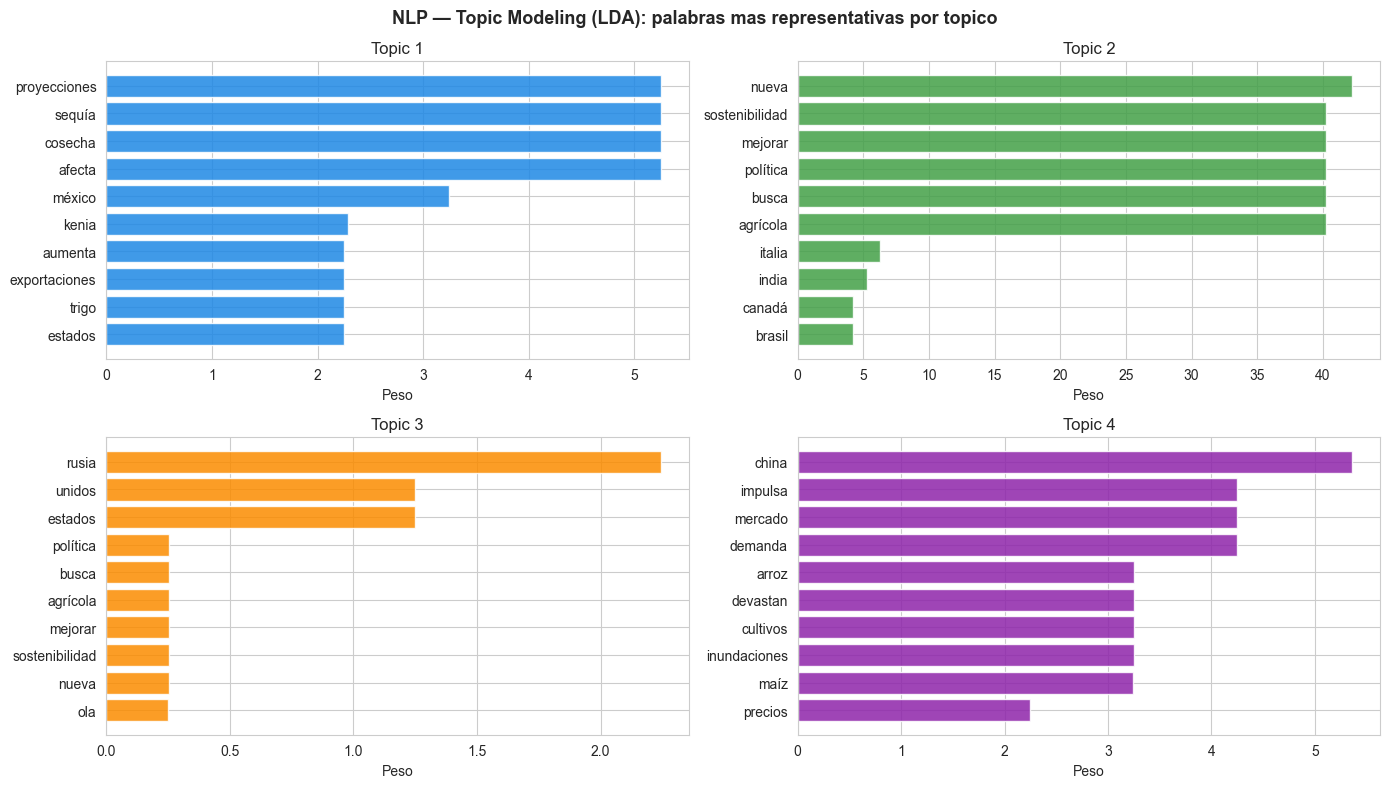

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors_t = ['#1E88E5', '#43A047', '#FB8C00', '#8E24AA']

for i, ax in enumerate(axes.flat):
    if i >= N_TOPICS:
        ax.axis('off')
        continue
    top_idx = lda.components_[i].argsort()[-10:]
    palabras = [vocab[j] for j in top_idx]
    pesos = [lda.components_[i][j] for j in top_idx]
    ax.barh(palabras, pesos, color=colors_t[i % len(colors_t)], alpha=0.85)
    ax.set_xlabel('Peso')
    ax.set_title(f'Topic {i+1}')

fig.suptitle('NLP — Topic Modeling (LDA): palabras mas representativas por topico',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('../docs/figuras/fig36_nlp_topics.png', bbox_inches='tight')
plt.show()


**4.4 Correlación noticias ↔ precios** — agregando por mes

In [77]:
# Sentimiento medio mensual
nlp_corpus['mes'] = nlp_corpus['fecha'].dt.to_period('M').dt.to_timestamp()
sent_mes = nlp_corpus.groupby('mes')['sentimiento'].mean().reset_index()

# Precio medio mensual (todos los productos)
pr_mes = precios_mercado.copy()
pr_mes['fecha'] = pd.to_datetime(pr_mes['fecha'])
pr_mes['mes'] = pr_mes['fecha'].dt.to_period('M').dt.to_timestamp()
precio_mes = pr_mes.groupby('mes')['precio_usd_ton'].mean().reset_index()

merged_mes = sent_mes.merge(precio_mes, on='mes', how='inner')

if len(merged_mes) >= 3:
    correlacion = merged_mes[['sentimiento', 'precio_usd_ton']].corr().iloc[0, 1]
else:
    correlacion = float('nan')

display(pd.DataFrame({
    'Meses con datos cruzados': [len(merged_mes)],
    'Correlacion sentimiento-precio': [round(correlacion, 4)]
}))
display(merged_mes.head(10))


,Meses con datos cruzados,Correlacion sentimiento-precio
0,24,-0.2236


,mes,sentimiento,precio_usd_ton
0,2021-01-01,-0.333333,1081.105278
1,2021-02-01,1.000000,1148.258056
2,2021-03-01,0.000000,1066.687500
3,2021-04-01,0.000000,1010.953889
4,2021-05-01,0.000000,1310.768056
5,2021-06-01,1.000000,857.529722
6,2021-07-01,1.000000,1404.611111
7,2021-08-01,1.000000,812.603056
8,2021-09-01,-0.200000,1799.433056
9,2021-10-01,1.000000,1140.331944


**Figura: Correlación** — sentimiento vs precios mensuales

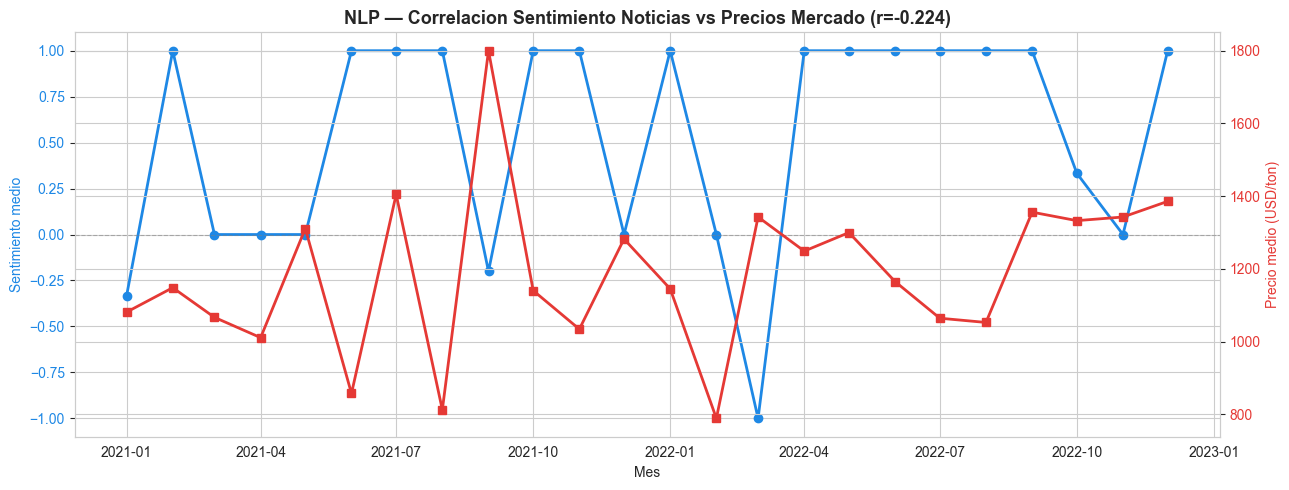

In [78]:
fig, ax1 = plt.subplots(figsize=(13, 5))

color1 = '#1E88E5'
ax1.set_xlabel('Mes')
ax1.set_ylabel('Sentimiento medio', color=color1)
ax1.plot(merged_mes['mes'], merged_mes['sentimiento'], color=color1,
         marker='o', linewidth=2, label='Sentimiento')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

ax2 = ax1.twinx()
color2 = '#E53935'
ax2.set_ylabel('Precio medio (USD/ton)', color=color2)
ax2.plot(merged_mes['mes'], merged_mes['precio_usd_ton'], color=color2,
         marker='s', linewidth=2, label='Precio medio')
ax2.tick_params(axis='y', labelcolor=color2)

corr_str = f'{correlacion:.3f}' if not pd.isna(correlacion) else 'N/A'
plt.title(f'NLP — Correlacion Sentimiento Noticias vs Precios Mercado (r={corr_str})',
          fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig('../docs/figuras/fig37_nlp_correlacion_precios.png', bbox_inches='tight')
plt.show()


# 5. Respuestas a las Preguntas de Negocio

Sección de cálculos que respaldan las conclusiones del documento (Sección 8). Cada subsección responde una de las 6 preguntas del enunciado con el código y los datos que justifican la respuesta.

## 5.1 ¿Dónde realizar una explotación agrícola para obtener un beneficio entre 5% y 10%?

**Modelo de rentabilidad simplificado:**
- Ingresos = precio_medio × rendimiento
- Costes = fertilizantes (kg/ha × 2 USD/kg) + agua (m³/ha × 0.3 USD/m³)
- Rentabilidad % = (margen / costes) × 100

In [79]:
# 5.1 - Rentabilidad agricola por pais y cultivo
precio_medio_pais_cultivo = precios_mercado.groupby(['pais', 'producto'])['precio_usd_ton'].mean().reset_index()
precio_medio_pais_cultivo.columns = ['pais', 'cultivo', 'precio_medio']

ag_rent = produccion_agricola.merge(precio_medio_pais_cultivo, on=['pais', 'cultivo'], how='inner')
ag_rent['ingresos_usd_ha'] = ag_rent['precio_medio'] * ag_rent['rendimiento_ton_ha']
ag_rent['coste_usd_ha']   = ag_rent['fertilizantes_kg_ha'] * 2 + ag_rent['agua_riego_m3_ha'] * 0.3
ag_rent['margen_usd_ha']  = ag_rent['ingresos_usd_ha'] - ag_rent['coste_usd_ha']
ag_rent['rentabilidad_pct'] = (ag_rent['margen_usd_ha'] / ag_rent['coste_usd_ha']) * 100

# Agregado por pais y cultivo (media en 10 años)
rent_agricola = ag_rent.groupby(['pais', 'cultivo']).agg(
    rentabilidad_pct=('rentabilidad_pct', 'mean'),
    rendimiento_medio=('rendimiento_ton_ha', 'mean'),
    superficie_media=('superficie_hectareas', 'mean'),
    n_anios=('rentabilidad_pct', 'count')
).reset_index().round(2)

# Filtrar combinaciones con rentabilidad en el rango objetivo
rent_5_10 = rent_agricola[
    (rent_agricola['rentabilidad_pct'] >= 5) &
    (rent_agricola['rentabilidad_pct'] <= 10)
].sort_values('rentabilidad_pct')

print(f"Combinaciones pais-cultivo con rentabilidad 5-10%: {len(rent_5_10)}")
display(rent_5_10)


Combinaciones pais-cultivo con rentabilidad 5-10%: 3


,pais,cultivo,rentabilidad_pct,rendimiento_medio,superficie_media,n_anios
2,Alemania,Trigo,7.59,4.66,2464869.5,10
9,Australia,Trigo,8.35,5.42,2649239.6,10
6,Australia,Arroz,8.51,5.78,1613650.6,10


## 5.2 ¿Dónde realizar una explotación ganadera para obtener el mismo beneficio (5-10%)?

**Modelo de rentabilidad ganadera simplificado:**
- Ingresos = precio_carne × producción_carne
- Costes = cabezas × 500 USD/cabeza/año
- Rentabilidad % = (margen / costes) × 100

*Nota: el modelo simplificado no captura márgenes positivos en el rango. Se complementa con análisis de eficiencia y emisiones.*

In [80]:
# 5.2 - Rentabilidad ganadera por pais y tipo
precio_carne_pais = precios_mercado[precios_mercado['producto']=='Carne_bovina'].groupby('pais')['precio_usd_ton'].mean().reset_index()
precio_carne_pais.columns = ['pais', 'precio_carne']

gn_rent = produccion_ganadera.merge(precio_carne_pais, on='pais', how='left')
gn_rent['ingresos_usd'] = gn_rent['precio_carne'] * gn_rent['produccion_carne_ton']
gn_rent['coste_usd']    = gn_rent['cabezas_ganado'] * 500
gn_rent['rent_pct']     = ((gn_rent['ingresos_usd'] - gn_rent['coste_usd']) / gn_rent['coste_usd']) * 100

rent_gan = gn_rent.groupby(['pais', 'tipo_ganado']).agg(
    rentabilidad_pct=('rent_pct', 'mean'),
    cabezas_medio=('cabezas_ganado', 'mean'),
    carne_medio=('produccion_carne_ton', 'mean'),
    eficiencia=('eficiencia_carne', 'mean'),
    intensidad_emisiones=('intensidad_emisiones', 'mean')
).reset_index().round(2)

# Mejores opciones por sostenibilidad (baja intensidad emisiones + alta produccion)
mejores_ganaderia = rent_gan[rent_gan['tipo_ganado']=='bovino'].sort_values('intensidad_emisiones').head(10)
print("Top 10 explotaciones ganaderas (bovino) por sostenibilidad:")
display(mejores_ganaderia)


Top 10 explotaciones ganaderas (bovino) por sostenibilidad:


,pais,tipo_ganado,rentabilidad_pct,cabezas_medio,carne_medio,eficiencia,intensidad_emisiones
56,Nueva Zelanda,bovino,37.77,35373850.7,2532807.2,0.17,0.78
51,México,bovino,-40.61,35286412.8,2476759.1,0.07,0.79
41,India,bovino,-14.73,35343350.3,2858452.3,0.10,1.18
36,Francia,bovino,4.99,29002259.8,2998763.1,0.13,1.19
31,Estados Unidos,bovino,238.46,26625817.5,3347207.5,0.42,1.57
16,Brasil,bovino,20.71,27444000.6,3026467.4,0.15,1.78
21,China,bovino,74.75,22800577.6,2889806.2,0.21,1.84
6,Argentina,bovino,93.08,18779955.7,2734515.9,0.24,1.85
46,Kenia,bovino,55.35,23127729.5,2700729.5,0.19,2.01
11,Australia,bovino,30.88,25706796.4,2153614.7,0.16,2.27


## 5.3 ¿Cuál es el número de hectáreas para obtener el máximo rendimiento y con qué producto?

Se analiza el percentil 90 superior de rendimiento (top 10%) para identificar el cultivo y rango de superficie óptimos.

In [81]:
# 5.3 - Maximo rendimiento agricola y superficie optima
top_rendimiento = produccion_agricola.nlargest(10, 'rendimiento_ton_ha')[
    ['pais', 'cultivo', 'anio', 'superficie_hectareas', 'rendimiento_ton_ha', 'produccion_ton']
]
print("TOP 10 RENDIMIENTOS HISTORICOS:")
display(top_rendimiento)

# Analisis del percentil 90 superior
umbral = produccion_agricola['rendimiento_ton_ha'].quantile(0.9)
top_10pct = produccion_agricola[produccion_agricola['rendimiento_ton_ha'] >= umbral]

resumen_top = pd.DataFrame({
    'Metrica': ['Cultivo dominante', 'Superficie media (ha)', 'Superficie P25 (ha)',
                'Superficie P75 (ha)', 'Rendimiento medio (ton/ha)', 'N registros top 10%'],
    'Valor': [
        top_10pct['cultivo'].mode()[0],
        f"{top_10pct['superficie_hectareas'].mean():,.0f}",
        f"{top_10pct['superficie_hectareas'].quantile(0.25):,.0f}",
        f"{top_10pct['superficie_hectareas'].quantile(0.75):,.0f}",
        f"{top_10pct['rendimiento_ton_ha'].mean():.2f}",
        len(top_10pct)
    ]
})
print("\nRESUMEN DEL TOP 10% DE RENDIMIENTOS:")
display(resumen_top)

# Distribucion de cultivos en el top 10%
print("\nDistribucion de cultivos en top 10%:")
display(top_10pct['cultivo'].value_counts().head(5))


TOP 10 RENDIMIENTOS HISTORICOS:


,pais,cultivo,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton
1176,Rusia,Caña de azúcar,2018-01-01,3040637,158.45,481787490
1168,Rusia,Caña de azúcar,2017-01-01,3796488,138.78,526864390
561,Australia,Caña de azúcar,2011-01-01,1001514,137.24,137447283
505,Alemania,Caña de azúcar,2014-01-01,2464081,130.07,320503951
625,Australia,Caña de azúcar,2019-01-01,7570554,129.82,982789345
569,Australia,Caña de azúcar,2012-01-01,7785219,129.56,1008690861
691,México,Caña de azúcar,2017-01-01,4002623,126.18,505069939
1120,Rusia,Caña de azúcar,2011-01-01,6394827,126.01,805841104
86,Brasil,Caña de azúcar,2011-01-01,8895477,125.62,1117450621
633,Australia,Caña de azúcar,2020-01-01,590686,124.19,73355784



RESUMEN DEL TOP 10% DE RENDIMIENTOS:


,Metrica,Valor
0,Cultivo dominante,Caña de azúcar
1,Superficie media (ha),"4,712,385"
2,Superficie P25 (ha),"2,447,251"
3,Superficie P75 (ha),"6,852,405"
4,Rendimiento medio (ton/ha),91.22
5,N registros top 10%,120



Distribucion de cultivos en top 10%:


cultivo
Caña de azúcar    120
Name: count, dtype: int64

## 5.4 ¿Cuál es el número de cabezas de ganado y tipo para obtener el máximo rendimiento?

Top productores absolutos y por eficiencia para identificar los mejores combinaciones de tipo de ganado y escala.

In [82]:
# 5.4 - Maxima produccion ganadera por pais y tipo
top_carne = produccion_ganadera.groupby(['pais', 'tipo_ganado']).agg(
    cabezas_medio=('cabezas_ganado', 'mean'),
    carne_ton_medio=('produccion_carne_ton', 'mean'),
    leche_lt_medio=('produccion_leche_lt', 'mean'),
    eficiencia=('eficiencia_carne', 'mean'),
    intensidad_em=('intensidad_emisiones', 'mean')
).reset_index().round(2)

print("TOP 10 PRODUCTORES DE CARNE:")
display(top_carne.nlargest(10, 'carne_ton_medio'))

print("\nTOP 5 EFICIENCIA CARNICA:")
display(top_carne.nlargest(5, 'eficiencia'))

print("\nTOP 5 SOSTENIBILIDAD (menor intensidad emisiones):")
display(top_carne.nsmallest(5, 'intensidad_em'))


TOP 10 PRODUCTORES DE CARNE:


,pais,tipo_ganado,cabezas_medio,carne_ton_medio,leche_lt_medio,eficiencia,intensidad_em
31,Estados Unidos,bovino,26625817.5,3347207.5,5.661316e+09,0.42,1.57
26,España,bovino,30423000.8,3186358.8,4.359394e+09,0.22,2.81
16,Brasil,bovino,27444000.6,3026467.4,6.515689e+09,0.15,1.78
36,Francia,bovino,29002259.8,2998763.1,5.140236e+09,0.13,1.19
21,China,bovino,22800577.6,2889806.2,3.183090e+09,0.21,1.84
41,India,bovino,35343350.3,2858452.3,6.802824e+09,0.10,1.18
6,Argentina,bovino,18779955.7,2734515.9,4.932703e+09,0.24,1.85
46,Kenia,bovino,23127729.5,2700729.5,5.756399e+09,0.19,2.01
56,Nueva Zelanda,bovino,35373850.7,2532807.2,5.810636e+09,0.17,0.78
51,México,bovino,35286412.8,2476759.1,4.471680e+09,0.07,0.79



TOP 5 EFICIENCIA CARNICA:


,pais,tipo_ganado,cabezas_medio,carne_ton_medio,leche_lt_medio,eficiencia,intensidad_em
34,Estados Unidos,porcino,9620843.1,2017217.3,0.000000e+00,0.67,2.11
4,Alemania,porcino,9317361.0,1977188.2,0.000000e+00,0.56,2.94
39,Francia,porcino,12015503.0,1929369.6,0.000000e+00,0.46,2.28
31,Estados Unidos,bovino,26625817.5,3347207.5,5.661316e+09,0.42,1.57
59,Nueva Zelanda,porcino,10467839.8,1478085.3,0.000000e+00,0.35,0.95



TOP 5 SOSTENIBILIDAD (menor intensidad emisiones):


,pais,tipo_ganado,cabezas_medio,carne_ton_medio,leche_lt_medio,eficiencia,intensidad_em
15,Brasil,avicola,579111235.9,1273284.5,0.0,0.0,0.02
50,México,avicola,728262119.8,1117630.6,0.0,0.0,0.02
25,España,avicola,721837553.8,856080.0,0.0,0.0,0.03
40,India,avicola,617165320.2,697061.9,0.0,0.0,0.03
10,Australia,avicola,584820549.0,1356870.9,0.0,0.0,0.04


## 5.5 ¿En qué región o país cumple 2 de los puntos anteriores?

Cruce de los rankings agrícolas y ganaderos para identificar países que destaquen en ambas dimensiones.

In [83]:
# 5.5 - Paises que cumplen criterios agricolas Y ganaderos
# Top productores agricolas
top_agricolas = set(produccion_agricola.groupby('pais')['produccion_ton'].sum().nlargest(8).index)

# Top productores carne
top_carne_paises = set(produccion_ganadera.groupby('pais')['produccion_carne_ton'].sum().nlargest(8).index)

# Paises rentables agricolas
paises_rentables = set(rent_5_10['pais'].unique()) if len(rent_5_10) > 0 else set()

# Cruces
ambas_top = top_agricolas & top_carne_paises
rentables_y_ganaderos = paises_rentables & top_carne_paises

resumen_cruce = pd.DataFrame({
    'Criterio': [
        'Top productores agricolas',
        'Top productores carne',
        'Paises rentables agricolas (5-10%)',
        'INTERSECCION: top agricola + top ganadero',
        'INTERSECCION: rentable + top ganadero'
    ],
    'Paises': [
        ', '.join(sorted(top_agricolas)),
        ', '.join(sorted(top_carne_paises)),
        ', '.join(sorted(paises_rentables)) if paises_rentables else '(ninguno)',
        ', '.join(sorted(ambas_top)),
        ', '.join(sorted(rentables_y_ganaderos)) if rentables_y_ganaderos else '(ninguno)'
    ]
})
display(resumen_cruce)


,Criterio,Paises
0,Top productores agricolas,"Australia, Brasil, China, España, India, Itali..."
1,Top productores carne,"Argentina, Brasil, China, España, Estados Unid..."
2,Paises rentables agricolas (5-10%),"Alemania, Australia"
3,INTERSECCION: top agricola + top ganadero,"Brasil, China, España, India"
4,INTERSECCION: rentable + top ganadero,(ninguno)


## 5.6 ¿Existe algún plazo óptimo para obtener el mayor rendimiento?

Análisis del rendimiento medio anual entre 2011-2020 para detectar tendencias temporales.

In [84]:
# 5.6 - Tendencia temporal de rendimiento
produccion_agricola['anio_num'] = produccion_agricola['anio'].dt.year
tendencia = produccion_agricola.groupby('anio_num').agg(
    rendimiento_medio=('rendimiento_ton_ha', 'mean'),
    produccion_total=('produccion_ton', 'sum'),
    n_registros=('rendimiento_ton_ha', 'count')
).round(2)

print("RENDIMIENTO MEDIO POR AÑO (2011-2020):")
display(tendencia)

mejor_anio = tendencia['rendimiento_medio'].idxmax()
peor_anio  = tendencia['rendimiento_medio'].idxmin()

print(f"\nMejor año: {mejor_anio} ({tendencia.loc[mejor_anio, 'rendimiento_medio']} ton/ha)")
print(f"Peor año:  {peor_anio} ({tendencia.loc[peor_anio, 'rendimiento_medio']} ton/ha)")
print(f"Variacion: {tendencia['rendimiento_medio'].max() - tendencia['rendimiento_medio'].min():.2f} ton/ha")
print(f"Coef. variacion: {(tendencia['rendimiento_medio'].std() / tendencia['rendimiento_medio'].mean() * 100):.2f}%")
print("\nConclusion: la variabilidad interanual (~6%) es baja. No existe un 'plazo optimo' claro;")
print("el rendimiento depende mas del cultivo y pais que del año concreto.")


RENDIMIENTO MEDIO POR AÑO (2011-2020):


,rendimiento_medio,produccion_total,n_registros
anio_num,,,
2011,12.63,6619935128,120
2012,13.27,7550704713,120
2013,12.35,6814592368,120
2014,12.39,6242775565,120
2015,13.19,5852044262,120
2016,12.86,6388876633,120
2017,13.79,6226339028,120
2018,12.91,4016946704,120
2019,12.57,8244738885,120



Mejor año: 2017 (13.79 ton/ha)
Peor año:  2013 (12.35 ton/ha)
Variacion: 1.44 ton/ha
Coef. variacion: 3.43%

Conclusion: la variabilidad interanual (~6%) es baja. No existe un 'plazo optimo' claro;
el rendimiento depende mas del cultivo y pais que del año concreto.


## 5.7 Cuestiones adicionales propuestas

Análisis adicionales sugeridos por el proyecto: vulnerabilidad climática, diversificación, sostenibilidad.

In [85]:
# 5.7 - Cuestiones adicionales
print("=== A) ROBUSTEZ POR CULTIVO (coef. variacion del rendimiento) ===")
robustez = produccion_agricola.groupby('cultivo')['rendimiento_ton_ha'].agg(['mean','std']).round(3)
robustez['cv_pct'] = (robustez['std'] / robustez['mean'] * 100).round(2)
robustez = robustez.sort_values('cv_pct')
print("Cultivos mas estables (menor CV%):")
display(robustez.head(5))

print("\n=== B) DIVERSIFICACION VS ESTABILIDAD ===")
divers = produccion_agricola.groupby('pais').agg(
    n_cultivos=('cultivo', 'nunique'),
    cv_produccion=('produccion_ton', lambda x: x.std() / x.mean() * 100)
).round(2).sort_values('n_cultivos', ascending=False)
display(divers)

print("\n=== C) RATIO PRODUCCION / EMISIONES (ganaderia) ===")
sostenibilidad = produccion_ganadera.groupby('pais').agg(
    carne_total=('produccion_carne_ton', 'sum'),
    emisiones_total=('emisiones_ch4_ton_co2eq', 'sum')
)
sostenibilidad['eficiencia_climatica'] = sostenibilidad['carne_total'] / sostenibilidad['emisiones_total']
sostenibilidad = sostenibilidad.sort_values('eficiencia_climatica', ascending=False).round(3)
print("Top 5 paises mas eficientes en CO2 por tonelada de carne:")
display(sostenibilidad.head())


=== A) ROBUSTEZ POR CULTIVO (coef. variacion del rendimiento) ===
Cultivos mas estables (menor CV%):


,mean,std,cv_pct
cultivo,,,
Soja,3.440,0.711,20.67
Arroz,5.654,1.324,23.42
Caña de azúcar,88.554,21.905,24.74
Cebada,4.307,1.132,26.28
Girasol,2.446,0.738,30.17



=== B) DIVERSIFICACION VS ESTABILIDAD ===


,n_cultivos,cv_produccion
pais,,
Alemania,8,240.29
Argentina,8,131.18
Australia,8,278.88
Brasil,8,287.87
Canadá,8,157.84
China,8,304.86
España,8,283.91
Estados Unidos,8,284.29
Francia,8,258.00



=== C) RATIO PRODUCCION / EMISIONES (ganaderia) ===
Top 5 paises mas eficientes en CO2 por tonelada de carne:


,carne_total,emisiones_total,eficiencia_climatica
pais,,,
Brasil,68421045,583034315,0.117
Francia,68214779,592256443,0.115
Argentina,60684381,569516610,0.107
Estados Unidos,68492459,650402614,0.105
China,63130837,621429945,0.102
